# Post-seg Heads (GT masks only)
No segmentation. Uses ground-truth JSON masks as `pL_all`/`pR_all`, then trains post-seg heads with early stopping.


In [1]:
# CELL 0 - CONFIG (LOCKED PATHS + TRAIN SETTINGS)

from pathlib import Path
import re

# Patient ID helper (used in later analytics)
def patient_base_from_link(link_value: str) -> str:
    base = Path(str(link_value)).stem
    return re.sub(r"_[0-9]+$", "", base)

# LOCKED
BASE_DIR  = Path(r"G:\Tasfique's")
CSV_PATH  = Path(r"G:\Tasfique's\dataset.csv")
JSON_PATH = Path(r"G:\Tasfique's\dmsa.json")
IMAGE_ROOT = BASE_DIR  # phase4a-style image root

# Segmentation CSV columns (phase4a-style)
COL_PATIENT = "PATIENT NAME"
COL_LINK    = "LINK"
COL_VIEW    = "VIEW"
COL_COUNT   = "Kidney COUNT"
COL_ANAT    = "ANATOMY"
COL_POS     = "POSITION"
IMG_SIZE  = 256
SEG_INPUT_SIZE = 256  # UNetSmall expects 256x256

# PREPROCESS (match uptake_aux)
P_LO = 1.0
P_HI = 99.0
USE_CLAHE = True

# TRAINING
BATCH_SIZE   = 6
EPOCHS       = 40
LR           = 2e-4
WEIGHT_DECAY = 1e-4

# EARLY STOP
EARLY_STOP_ON     = True
EARLY_STOP_METRIC = "val_f1m"
PATIENCE          = 7
MIN_DELTA         = 1e-4

# CHECKPOINTS (Phase4A UNetSmall)
SEG_CKPT_PATH = BASE_DIR / "phase4a_seg_outputs" / "best_unet.pt"
SEG_CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)

# OPTIONAL CACHE
MAKE_FULL_MASK_CACHE = False
MASK_CACHE_PATH = BASE_DIR / "pred_masks_cache_unet_small.npz"
GT_MASK_CACHE_PATH = BASE_DIR / "gt_masks_cache_postseg.npz"

# OVERSAMPLING (segmentation)
OVERSAMPLE_ONE_KIDNEY  = 8.0
OVERSAMPLE_TWO_KIDNEY  = 1.0
OVERSAMPLE_ZERO_KIDNEY = 1.0

# POSTPROCESS (reduce false positives)
POSTPROCESS_PRED  = False
MIN_COMP_PIXELS   = 200
MIN_AREA_PIXELS   = 300
AREA_RATIO_DROP   = 0.20

# PRESENCE LOSS (discourage false 2-kidney)
PRESENCE_W = 0.2
PRESENT_MIN_PIXELS_256 = 150

# OTHER
MASK_THR = 0.5
SEED = 42
NUM_WORKERS = 0

print("CONFIG OK")
print("BASE_DIR:", BASE_DIR)
print("CSV_PATH:", CSV_PATH)
print("JSON_PATH:", JSON_PATH)
print("IMG_SIZE:", IMG_SIZE, "| SEG_INPUT_SIZE:", SEG_INPUT_SIZE)
print("CKPT:", SEG_CKPT_PATH)

# Segmentation augmentation (phase4a)
AUG_FLIP_P = 0.5
AUG_ROT_DEG = 8.0


CONFIG OK
BASE_DIR: G:\Tasfique's
CSV_PATH: G:\Tasfique's\dataset.csv
JSON_PATH: G:\Tasfique's\dmsa.json
IMG_SIZE: 256 | SEG_INPUT_SIZE: 256
CKPT: G:\Tasfique's\phase4a_seg_outputs\best_unet.pt


In [2]:
# CELL 1 - IMPORTS + DEVICE + SEED + MEMORY

import os, json, random, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# DirectML for AMD GPU
try:
    import torch_directml
    HAS_DIRECTML = torch_directml.is_available()
except Exception:
    HAS_DIRECTML = False

# Optional cv2
try:
    import cv2
    HAS_CV2 = True
except Exception:
    cv2 = None
    HAS_CV2 = False

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False

seed_all(SEED)

# Use DirectML for AMD GPU, fallback to CUDA or CPU
if HAS_DIRECTML:
    DEVICE = torch_directml.device()
    print("DEVICE: DirectML (AMD GPU)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("DEVICE: CUDA (NVIDIA GPU)")
else:
    DEVICE = torch.device("cpu")
    print("DEVICE: CPU")
print("cv2 available:", HAS_CV2)

def mem_status():
    ram = ""
    try:
        import psutil
        vm = psutil.virtual_memory()
        ram = f"RAM {vm.used/1e9:.1f}/{vm.total/1e9:.1f}GB"
    except Exception:
        ram = "RAM (psutil not installed)"
    gpu = ""
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / (1024**3)
        r = torch.cuda.memory_reserved() / (1024**3)
        gpu = f" | GPU alloc {a:.2f}GB reserv {r:.2f}GB"
    return ram + gpu


DEVICE: DirectML (AMD GPU)
cv2 available: False


c:\Users\muhta\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# CELL 1.1 - GPU REQUIRED (FAIL FAST IF CPU)

GPU_BACKEND = None

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    GPU_BACKEND = "cuda"
else:
    try:
        import torch_directml
        _dml_device = torch_directml.device()
        # Sanity check that tensors can be placed on the GPU backend.
        _ = torch.tensor([1.0], device=_dml_device) * 2.0
        DEVICE = _dml_device
        GPU_BACKEND = "directml"
    except Exception as _gpu_err:
        GPU_BACKEND = None
        _GPU_ERR = _gpu_err

if GPU_BACKEND is None:
    raise RuntimeError(
        "GPU is required but was not detected. This notebook will not run on CPU.\n"
        "If you are on AMD/Windows, install torch-directml and update GPU drivers.\n"
        f"Underlying error: {repr(globals().get('_GPU_ERR', None))}"
    )

print(f"GPU backend locked: {GPU_BACKEND} | DEVICE: {DEVICE}")


GPU backend locked: directml | DEVICE: privateuseone:0


In [4]:
# CELL 2 - LOAD CSV + JSON (NO GUESSING) + PRINT EXACT VALUES

assert BASE_DIR.exists(), f"BASE_DIR not found: {BASE_DIR}"
assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH}"
assert JSON_PATH.exists(), f"JSON not found: {JSON_PATH}"

df = pd.read_csv(CSV_PATH)

# phase4a-style helpers
df["_LINK_NORM"] = df[COL_LINK].astype(str).str.replace("\\", "/", regex=False)
df["_BASENAME"]  = df["_LINK_NORM"].apply(lambda x: os.path.basename(x))

with open(JSON_PATH, "r", encoding="utf-8") as f:
    dmsa_json = json.load(f)

print("CSV shape:", df.shape)
print("JSON images:", len(dmsa_json))

print("\nCSV columns (exact):")
for c in df.columns.tolist():
    print(" -", repr(c))

for c in ["LINK", "VIEW"]:
    assert c in df.columns, f"Missing required column: {c}"

print("\nVIEW unique values (exact):", [repr(x) for x in df["VIEW"].astype(str).dropna().unique().tolist()])
print("First 5 LINK:", [repr(x) for x in df["LINK"].astype(str).head(5).tolist()])

labels_found = set()
rc_hist = {}
seen = 0
for k,v in dmsa_json.items():
    regs = v.get("regions", None)
    if isinstance(regs, dict):
        rc_hist[len(regs)] = rc_hist.get(len(regs), 0) + 1
        for rid, reg in regs.items():
            lab = reg.get("region_attributes", {}).get("label", None)
            if lab is not None:
                labels_found.add(str(lab))
        seen += 1
    if seen >= 200:
        break

print("\nJSON labels found (sample):", sorted(list(labels_found)))
print("JSON regions count histogram (sample):", rc_hist)
print("\nLoaded CSV+JSON.")
print("Unique basenames:", df["_BASENAME"].nunique())


CSV shape: (2294, 25)
JSON images: 2294

CSV columns (exact):
 - 'PATIENT NAME'
 - 'AGE'
 - 'AGE in MONTHS'
 - 'SEX'
 - 'LINK'
 - 'VIEW'
 - 'SIZE LEFT'
 - 'SIZE RIGHT'
 - 'ANATOMY'
 - 'SHAPE LEFT'
 - 'SHAPE RIGHT'
 - 'POSITION'
 - 'ECTOPIC POSITION LEFT'
 - 'ECTOPIC POSITION RIGHT'
 - 'Kidney COUNT'
 - 'SCAR'
 - 'SCAR LEFT'
 - 'SCAR RIGHT'
 - 'HDN'
 - 'CORTICAL UPTAKE LEFT'
 - 'CORTICAL UPTAKE RIGHT'
 - 'Comment'
 - 'CH'
 - '_LINK_NORM'
 - '_BASENAME'

VIEW unique values (exact): ["'P'", "'LPO'", "'RPO'"]
First 5 LINK: ["'Data\\\\A_RAHMAN_6_MONTHS.jpeg'", "'Data\\\\A_RAHMAN_6_MONTHS_1.jpeg'", "'Data\\\\A_RAHMAN_6_MONTHS_2.jpeg'", "'Data\\\\ABDUL_ALIM_1_MONTHS.jpeg'", "'Data\\\\ABDUL_ALIM_1_MONTHS_1.jpeg'"]

JSON labels found (sample): ['left', 'right']
JSON regions count histogram (sample): {2: 157, 1: 43}

Loaded CSV+JSON.
Unique basenames: 2294


In [5]:
# CELL 3 - LOCKED PREPROCESS + MASK LOADING (ROI+CLIP+DENOISE+CLAHE, MASK FIRST THEN FLIP)

import numpy as np
from pathlib import Path
from PIL import Image

_HAS_CV2 = HAS_CV2
_HAS_SKIMAGE = False
try:
    from skimage import exposure
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False

print("CLAHE backend -> cv2:", _HAS_CV2, "| skimage:", _HAS_SKIMAGE)

# ROI (ignore 30px border -> 196x196 active)
IGNORE_BORDER = 30
ROI_Y0, ROI_Y1 = IGNORE_BORDER, IMG_SIZE - IGNORE_BORDER
ROI_X0, ROI_X1 = IGNORE_BORDER, IMG_SIZE - IGNORE_BORDER
ROI_U8 = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
ROI_U8[ROI_Y0:ROI_Y1, ROI_X0:ROI_X1] = 1
ROI_F = ROI_U8.astype(np.float32)

def read_gray_image(path: Path) -> np.ndarray:
    img = Image.open(path).convert("L")
    if img.size != (IMG_SIZE, IMG_SIZE):
        img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
    return np.asarray(img, dtype=np.uint8)

def read_gray_256(path: Path) -> np.ndarray:
    return read_gray_image(path).astype(np.float32) / 255.0

def polygon_to_mask(xs, ys):
    pts = np.stack([np.array(xs, np.int32), np.array(ys, np.int32)], axis=1).reshape((-1,1,2))
    m = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    if _HAS_CV2:
        cv2.fillPoly(m, [pts], 1)
    else:
        from PIL import ImageDraw
        im = Image.new("L", (IMG_SIZE, IMG_SIZE), 0)
        ImageDraw.Draw(im).polygon([tuple(p[0]) for p in pts], outline=1, fill=1)
        m = np.array(im, dtype=np.uint8)
    return m

def load_manual_masks_for_image(filename: str):
    entry = dmsa_json.get(filename, None)
    if entry is None:
        return None, None
    regs = entry.get("regions", {})
    if not isinstance(regs, dict):
        return None, None
    ML = None
    MR = None
    for rid, reg in regs.items():
        shape = reg.get("shape_attributes", {})
        ra = reg.get("region_attributes", {})
        lab = ra.get("label", None)
        if lab is None:
            continue
        lab_s = str(lab).strip().lower()
        xs = shape.get("all_points_x", None)
        ys = shape.get("all_points_y", None)
        if xs is None or ys is None:
            continue
        m = polygon_to_mask(xs, ys)
        if lab_s == "left":
            ML = m if ML is None else np.maximum(ML, m)
        elif lab_s == "right":
            MR = m if MR is None else np.maximum(MR, m)
    return ML, MR

def flip_if_rpo(view_str: str, img_u8: np.ndarray, ML, MR):
    if str(view_str).strip() == "RPO":
        img_u8 = np.ascontiguousarray(np.fliplr(img_u8))
        if ML is not None: ML = np.ascontiguousarray(np.fliplr(ML))
        if MR is not None: MR = np.ascontiguousarray(np.fliplr(MR))
    return img_u8, ML, MR

def intensity_clip_norm(I: np.ndarray, mask: np.ndarray = None, p_lo=1.0, p_hi=99.0):
    X = I
    if mask is not None:
        m = mask.astype(bool)
        vals = X[m]
        if vals.size < 32:
            vals = X.reshape(-1)
    else:
        vals = X.reshape(-1)
    lo = np.percentile(vals, p_lo)
    hi = np.percentile(vals, p_hi)
    if hi <= lo + 1e-6:
        return np.clip(X, 0.0, 1.0)
    Y = np.clip(X, lo, hi)
    Y = (Y - lo) / (hi - lo)
    return np.clip(Y, 0.0, 1.0)

def gentle_denoise(I: np.ndarray):
    if _HAS_CV2:
        return cv2.GaussianBlur(I.astype(np.float32), (3, 3), sigmaX=0.5)
    return I

def apply_clahe(I: np.ndarray):
    if _HAS_CV2:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        u8 = np.clip(I * 255.0, 0, 255).astype(np.uint8)
        return clahe.apply(u8).astype(np.float32) / 255.0
    if _HAS_SKIMAGE:
        return exposure.equalize_adapthist(I, clip_limit=0.02).astype(np.float32)
    return I

def preprocess_for_model(I_raw_01, ML, MR, p_lo=P_LO, p_hi=P_HI, do_clahe=True):
    stat_mask = ROI_U8.copy().astype(bool)
    if ML is not None or MR is not None:
        km = np.zeros_like(ROI_U8, dtype=bool)
        if ML is not None: km |= (ML.astype(bool))
        if MR is not None: km |= (MR.astype(bool))
        stat_mask &= km

    I_roi = I_raw_01 * ROI_F
    I_clip = intensity_clip_norm(I_roi, mask=stat_mask, p_lo=p_lo, p_hi=p_hi)
    I_dnz = gentle_denoise(I_clip)
    I_clahe = apply_clahe(I_dnz) if do_clahe else I_dnz
    return I_clahe

def resize_img_float(I, size):
    if _HAS_CV2:
        return cv2.resize(I, (size, size), interpolation=cv2.INTER_LINEAR)
    return np.array(Image.fromarray((I*255).astype(np.uint8)).resize((size,size), Image.BILINEAR)).astype(np.float32)/255.0

def resize_label(mask, size):
    if _HAS_CV2:
        out = cv2.resize(mask.astype(np.uint8), (size, size), interpolation=cv2.INTER_NEAREST)
    else:
        out = np.array(Image.fromarray(mask.astype(np.uint8)).resize((size,size), Image.NEAREST))
    return out.astype(np.int64)

def resize_mask(mask, size):
    if mask is None:
        return None
    if _HAS_CV2:
        out = cv2.resize(mask.astype(np.uint8), (size, size), interpolation=cv2.INTER_NEAREST)
    else:
        out = np.array(Image.fromarray(mask.astype(np.uint8)).resize((size,size), Image.NEAREST))
    return (out > 0).astype(np.uint8)

def preprocess_locked(img_u8: np.ndarray):
    I01 = img_u8.astype(np.float32) / 255.0
    return preprocess_for_model(I01, ML=None, MR=None, p_lo=P_LO, p_hi=P_HI, do_clahe=USE_CLAHE)

# ---- Phase4A-style segmentation helpers (separate from post-seg preprocess) ----
IMG_H = IMG_SIZE
IMG_W = IMG_SIZE

def _norm_label_seg(x):
    if x is None:
        return None
    s = str(x).strip().lower()
    if s in ["l", "left"]:
        return "left"
    if s in ["r", "right"]:
        return "right"
    return s

def _extract_regions_from_entry_seg(entry):
    regions = []
    # VGG-style
    if isinstance(entry, dict) and "regions" in entry:
        rs = entry["regions"]
        if isinstance(rs, dict):
            rs = list(rs.values())
        if isinstance(rs, list):
            for reg in rs:
                if not isinstance(reg, dict):
                    continue
                sa = reg.get("shape_attributes", {})
                ra = reg.get("region_attributes", {})
                if sa.get("name") != "polygon":
                    continue
                xs = sa.get("all_points_x", [])
                ys = sa.get("all_points_y", [])
                lab = ra.get("label", ra.get("side", ra.get("kidney", ra.get("name", None))))
                lab = _norm_label_seg(lab)
                regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    # List format
    if isinstance(entry, list):
        for reg in entry:
            if not isinstance(reg, dict):
                continue
            xs = reg.get("all_points_x") or reg.get("xs") or []
            ys = reg.get("all_points_y") or reg.get("ys") or []
            lab = _norm_label_seg(reg.get("label", reg.get("side", reg.get("name", None))))
            regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    # Custom key
    if isinstance(entry, dict) and "polygons" in entry:
        for reg in entry["polygons"]:
            xs = reg.get("x", reg.get("xs", []))
            ys = reg.get("y", reg.get("ys", []))
            lab = _norm_label_seg(reg.get("label", reg.get("side", None)))
            regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    return regions

mask_db_seg = {}
if isinstance(dmsa_json, dict):
    for k, v in dmsa_json.items():
        base = os.path.basename(str(k).replace('\\','/'))
        regs = _extract_regions_from_entry_seg(v)
        if len(regs) > 0:
            mask_db_seg[base] = regs
elif isinstance(dmsa_json, list):
    for item in dmsa_json:
        if not isinstance(item, dict):
            continue
        fname = item.get("filename", item.get("file", item.get("image", None)))
        if fname is None:
            continue
        base = os.path.basename(str(fname).replace('\\','/'))
        regs = _extract_regions_from_entry_seg(item)
        if len(regs) > 0:
            mask_db_seg[base] = regs

print("Mask files in JSON (seg):", len(mask_db_seg))

df["_HAS_MASK"] = df["_BASENAME"].apply(lambda b: b in mask_db_seg)
print("CSV rows with mask (seg):", int(df["_HAS_MASK"].sum()))

def resolve_image_path_from_csv_row_seg(row):
    rel = row["_LINK_NORM"]
    cand = os.path.join(str(IMAGE_ROOT), rel)
    if os.path.exists(cand):
        return cand

    base = row["_BASENAME"]
    cand1 = os.path.join(str(IMAGE_ROOT), base)
    if os.path.exists(cand1):
        return cand1

    for root, _, files in os.walk(str(IMAGE_ROOT)):
        if base in files:
            return os.path.join(root, base)

    raise FileNotFoundError(f"Image not found for basename: {base}")

def load_image_gray256_seg(path):
    img = Image.open(path).convert("L").resize((IMG_W, IMG_H), resample=Image.BILINEAR)
    return np.array(img, dtype=np.uint8)

def polygons_to_mask_seg(regions):
    m = np.zeros((IMG_H, IMG_W), dtype=np.uint8)
    for reg in regions:
        lab = _norm_label_seg(reg.get("label"))
        xs = reg.get("xs", [])
        ys = reg.get("ys", [])
        if lab not in ["left", "right"]:
            continue
        if xs is None or ys is None:
            continue
        if len(xs) < 3 or len(ys) < 3:
            continue
        pts = np.stack([np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)], axis=1)
        pts[:,0] = np.clip(pts[:,0], 0, IMG_W-1)
        pts[:,1] = np.clip(pts[:,1], 0, IMG_H-1)
        pts_i = pts.astype(np.int32).reshape((-1,1,2))
        cls = 1 if lab == "left" else 2
        if HAS_CV2:
            cv2.fillPoly(m, [pts_i], cls)
        else:
            # fallback if cv2 missing
            from PIL import ImageDraw
            im = Image.new("L", (IMG_W, IMG_H), 0)
            ImageDraw.Draw(im).polygon([tuple(p[0]) for p in pts_i], outline=int(cls), fill=int(cls))
            m = np.maximum(m, np.array(im, dtype=np.uint8))
    return m


CLAHE backend -> cv2: False | skimage: False
Mask files in JSON (seg): 2294
CSV rows with mask (seg): 2294


In [6]:
# BUILD GT MASKS (pL_all, pR_all) AND FILTER DF
# Align masks to the filtered df index so downstream code can use row indices directly.

df = df[df["_HAS_MASK"]].copy().reset_index(drop=True)
print("Filtered rows with masks:", len(df))

pL_all = np.zeros((len(df), IMG_SIZE, IMG_SIZE), dtype=np.uint8)
pR_all = np.zeros((len(df), IMG_SIZE, IMG_SIZE), dtype=np.uint8)

missing = 0
for i in tqdm(range(len(df)), desc="GT masks"):
    row = df.iloc[i]
    base = row["_BASENAME"]
    view = str(row[COL_VIEW]) if COL_VIEW in row else ""

    regs = mask_db_seg.get(base)
    if regs is None:
        missing += 1
        continue

    mask = polygons_to_mask_seg(regs)

    # Match the post-seg convention used by the predicted-mask cache.
    if view.strip().upper() == "RPO":
        mask = mask[:, ::-1].copy()

    mL = (mask == 1).astype(np.uint8)
    mR = (mask == 2).astype(np.uint8)

    # Apply the same ROI used elsewhere.
    pL_all[i] = (mL * ROI_U8).astype(np.uint8)
    pR_all[i] = (mR * ROI_U8).astype(np.uint8)

print("Missing after filter:", missing)
print("pL_all shape:", pL_all.shape, "| pR_all shape:", pR_all.shape)
np.savez_compressed(GT_MASK_CACHE_PATH, pL=pL_all, pR=pR_all)
print("Saved GT mask cache:", GT_MASK_CACHE_PATH)


Filtered rows with masks: 2294


GT masks: 100%|██████████| 2294/2294 [00:00<00:00, 2418.66it/s]


Missing after filter: 0
pL_all shape: (2294, 256, 256) | pR_all shape: (2294, 256, 256)
Saved GT mask cache: G:\Tasfique's\gt_masks_cache_postseg.npz


In [7]:
# CELL 20 - POST-SEG SETUP (LOCKED RULES + LABEL MAPS + VIEW WEIGHTS + OVERSAMPLING)

import math, time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import defaultdict

# ---- Locked columns (exact from CSV) ----
COL_PID   = "PATIENT NAME"
COL_VIEW  = "VIEW"
COL_LINK  = "LINK"
COL_COUNT = "Kidney COUNT"
COL_ANAT  = "ANATOMY"
COL_POS   = "POSITION"
COL_SZ_L  = "SIZE LEFT"
COL_SZ_R  = "SIZE RIGHT"
COL_UP_L  = "CORTICAL UPTAKE LEFT"
COL_UP_R  = "CORTICAL UPTAKE RIGHT"

def norm_str(x):
    if x is None:
        return ""
    return str(x).strip().upper()

VIEW_ORDER = ["P", "LPO", "RPO"]
VIEW_TO_I = {v:i for i,v in enumerate(VIEW_ORDER)}

# SIZE: P 75%, others total 25%
W_SIZE = np.array([0.75, 0.125, 0.125], dtype=np.float32)

# POSITION + ANAT_STAGE1: Posterior highest; LPO/RPO roughly same
W_POS_ANAT1 = np.array([0.60, 0.20, 0.20], dtype=np.float32)

# UPTAKE: Posterior highest; then side-specific order
W_UP_L = np.array([0.60, 0.25, 0.15], dtype=np.float32)  # P > LPO > RPO
W_UP_R = np.array([0.60, 0.15, 0.25], dtype=np.float32)  # P > RPO > LPO

OVERSAMPLE = {
    "POSITION": {"NORMAL RENAL FOSSA": 1, "ECTOPIC": 8},
    "ANAT2":    {"ECTOPIC": 6, "HORSHOE": 25, "NORMAL": 1},
    "SIZE_L":   {"SMALLER": 4, "BIGGER": 4, "NORMAL": 1},
    "SIZE_R":   {"SMALLER": 4, "BIGGER": 4, "NORMAL": 1},
    "UP_L":     {"REDUCED": 2, "NORMAL": 1},
    "UP_R":     {"REDUCED": 2, "NORMAL": 1},
}

print("OK Post-seg setup OK")

OK Post-seg setup OK


In [8]:
# CELL 21 - BUILD PATIENT INDEX + PATIENT SPLIT (80/10/10) - WITH HORSESHOE COVERAGE GUARD

import numpy as np
from collections import defaultdict

pid_to_rows = defaultdict(dict)
for i in range(len(df)):
    pid = str(df.iloc[i][COL_PID]).strip()
    v = norm_str(df.iloc[i][COL_VIEW])
    if v in VIEW_TO_I:
        pid_to_rows[pid][v] = i

patients = sorted(pid_to_rows.keys())

rng = np.random.default_rng(SEED)
rng.shuffle(patients)

n = len(patients)
n_train = int(round(0.80 * n))
n_val = int(round(0.10 * n))

train_p = patients[:n_train]
val_p = patients[n_train:n_train + n_val]
test_p = patients[n_train + n_val:]


def _anat_label_pid(pid):
    rows = pid_to_rows.get(pid, {})
    ri = rows.get("P") if "P" in rows else (rows.get("LPO") if "LPO" in rows else rows.get("RPO"))
    if ri is None:
        return ""
    lab = norm_str(df.iloc[int(ri)].get(COL_ANAT, ""))
    if lab == "HORSHOE":
        lab = "HORSESHOE"
    return lab


def _label_counts(pids):
    from collections import Counter
    c = Counter()
    for pid in pids:
        c[_anat_label_pid(pid)] += 1
    return c


def _ensure_label_in_split(label, split_name, split_list, donor_list):
    if any(_anat_label_pid(pid) == label for pid in split_list):
        return

    donor = next((pid for pid in donor_list if _anat_label_pid(pid) == label), None)
    if donor is None:
        print(f"WARN: no '{label}' patient available to move into {split_name} split")
        return

    # Swap with a non-target label if possible to keep label coverage.
    swap_idx = next((i for i, pid in enumerate(split_list) if _anat_label_pid(pid) != label), 0)
    swap_pid = split_list[swap_idx]

    donor_list.remove(donor)
    donor_list.append(swap_pid)
    split_list[swap_idx] = donor
    print(f"Adjusted splits: moved '{label}' patient into {split_name} split")


# Ensure HORSESHOE appears in validation for Stage-2 metrics/early-stop signals.
_ensure_label_in_split("HORSESHOE", "val", val_p, train_p)

print("Patients total:", n, "| train:", len(train_p), "| val:", len(val_p), "| test:", len(test_p))


def view_coverage(pids):
    c = np.zeros(3, dtype=int)
    for pid in pids:
        for v in pid_to_rows[pid].keys():
            c[VIEW_TO_I[v]] += 1
    return c


print("Train view coverage [P,LPO,RPO]:", view_coverage(train_p).tolist())
print("Val   view coverage [P,LPO,RPO]:", view_coverage(val_p).tolist())
print("Test  view coverage [P,LPO,RPO]:", view_coverage(test_p).tolist())

print("Anatomy label counts (train):", dict(_label_counts(train_p)))
print("Anatomy label counts (val):", dict(_label_counts(val_p)))
print("Anatomy label counts (test):", dict(_label_counts(test_p)))


Adjusted splits: moved 'HORSESHOE' patient into val split
Patients total: 593 | train: 474 | val: 59 | test: 60
Train view coverage [P,LPO,RPO]: [473, 472, 471]
Val   view coverage [P,LPO,RPO]: [59, 59, 59]
Test  view coverage [P,LPO,RPO]: [60, 60, 60]
Anatomy label counts (train): {'NORMAL': 343, 'SINGLE': 94, 'ECTOPIC': 30, 'HORSESHOE': 7}
Anatomy label counts (val): {'HORSESHOE': 1, 'SINGLE': 17, 'NORMAL': 37, 'ECTOPIC': 4}
Anatomy label counts (test): {'NORMAL': 40, 'HORSESHOE': 2, 'SINGLE': 11, 'ECTOPIC': 7}


In [9]:
# CELL 22 - INPUT BUILDERS (4-CH) + MAJOR-AXIS FEATURES (FROM PRED MASKS) + PATIENT HELPERS

import numpy as np
import math

def _get_row_view_tensor(i_row):
    row = df.iloc[int(i_row)]
    link = str(row[COL_LINK])
    view = norm_str(row[COL_VIEW])

    img_u8 = read_gray_image(BASE_DIR / link)

    # Standardize image orientation if RPO (same as cache inference)
    if view == "RPO":
        img_u8 = np.fliplr(img_u8).copy()

    I = preprocess_locked(img_u8).astype(np.float32)
    mL = pL_all[int(i_row)].astype(np.uint8)
    mR = pR_all[int(i_row)].astype(np.uint8)
    return I, mL, mR

def build_input4(I, mL, mR, mode):
    I = I.astype(np.float32)
    u = ((mL + mR) > 0).astype(np.float32)

    if mode == "SIZE":
        x0 = I
        x1 = I * u
        x2 = I * mL.astype(np.float32)
        x3 = I * mR.astype(np.float32)
    elif mode == "UP_L":
        m = mL.astype(np.float32)
        x0 = I
        x1 = I * m
        x2 = m
        x3 = I * (1.0 - m)
    elif mode == "UP_R":
        m = mR.astype(np.float32)
        x0 = I
        x1 = I * m
        x2 = m
        x3 = I * (1.0 - m)
    else:
        x0 = I
        x1 = I * u
        x2 = u
        x3 = I * (1.0 - u)

    return np.stack([x0,x1,x2,x3], axis=0).astype(np.float32)

def major_axis_len(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) < 20:
        return 0.0
    pts = np.stack([xs, ys], axis=1).astype(np.float32)
    pts -= pts.mean(axis=0, keepdims=True)
    cov = (pts.T @ pts) / max(len(pts)-1, 1)
    w = np.linalg.eigvalsh(cov)
    lam = float(w[-1])
    return 4.0 * math.sqrt(max(lam, 1e-8))

def patient_views(pid):
    m = pid_to_rows.get(pid, {})
    return [m.get("P", None), m.get("LPO", None), m.get("RPO", None)]

def patient_presence(pid):
    rows = patient_views(pid)
    L = 0; R = 0
    for ri in rows:
        if ri is None:
            continue
        if int(pL_all[ri].sum()) > 0: L = 1
        if int(pR_all[ri].sum()) > 0: R = 1
    return L, R

print("OK Post-seg input builders ready")

OK Post-seg input builders ready


In [10]:
# CELL 23 - METRICS: CONFUSION MATRIX + PER-CLASS F1 + MACRO F1 + PLOT

import numpy as np
import matplotlib.pyplot as plt

def confusion_matrix_np(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t,p in zip(y_true, y_pred):
        t = int(t); p = int(p)
        if 0 <= t < n_classes and 0 <= p < n_classes:
            cm[t,p] += 1
    return cm

def f1_macro_from_cm(cm):
    f1s = []
    for c in range(cm.shape[0]):
        tp = cm[c,c]
        fp = cm[:,c].sum() - tp
        fn = cm[c,:].sum() - tp
        den = (2*tp + fp + fn)
        f1 = (2*tp/den) if den > 0 else 0.0
        f1s.append(float(f1))
    return f1s, float(np.mean(f1s))

def plot_cm(cm, title, names):
    plt.figure(figsize=(5.4,4.8))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Pred"); plt.ylabel("True")
    plt.xticks(range(len(names)), names, rotation=45)
    plt.yticks(range(len(names)), names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(int(cm[i,j])), ha="center", va="center")
    plt.tight_layout()
    plt.show()

POSITION samples (all): 593
POSITION macro F1 (all): 0.7688 | per-class: [0.9341, 0.6036]


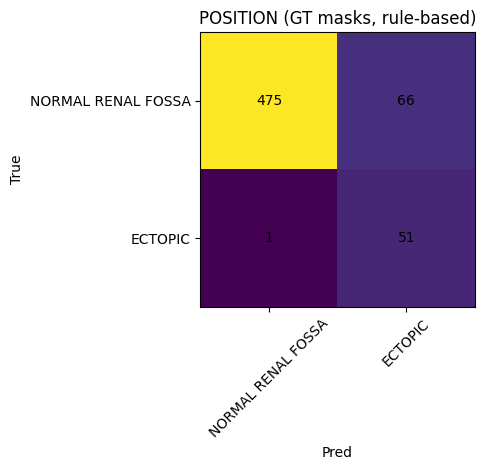

POSITION macro F1 (derived count==2): 0.7609 | per-class: [0.9147, 0.6071]


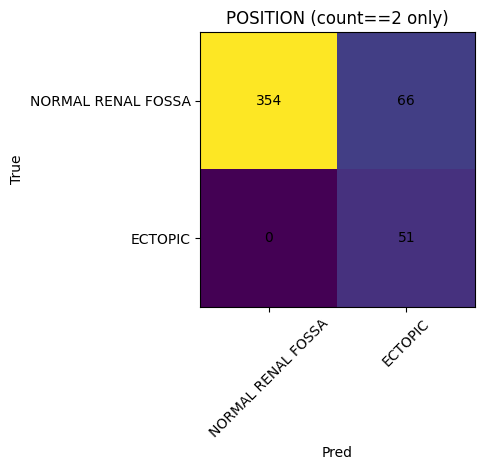

In [11]:
# CELL 23.6 - POSITION head (GT masks only, rule-based, P-dominant)

import numpy as np

POS_LABELS = ["NORMAL RENAL FOSSA", "ECTOPIC"]
POS_TO_I = {s: i for i, s in enumerate(POS_LABELS)}

# Tunable geometry thresholds for "normal" appearance.
SIDE_BY_SIDE_DX_FRAC = 0.55
SAME_AXIS_DY_FRAC = 0.35
CLEAR_GAP_FRAC = 0.10
CLEAR_GAP_PIX = 6
POS_THRESHOLD = 0.50


def _patient_label_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
    return df.iloc[int(ri)]


def _mask_stats(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0 = int(xs.min()); x1 = int(xs.max())
    y0 = int(ys.min()); y1 = int(ys.max())
    area = int(xs.size)
    cx = float(xs.mean()); cy = float(ys.mean())
    w = float(x1 - x0 + 1); h = float(y1 - y0 + 1)
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1, "area": area, "cx": cx, "cy": cy, "w": w, "h": h}


def _view_normal_flags(mL, mR):
    sL = _mask_stats(mL); sR = _mask_stats(mR)
    if sL is None or sR is None:
        return False, {"reason": "missing"}

    # Order by horizontal position (left-to-right).
    a, b = (sL, sR) if sL["cx"] <= sR["cx"] else (sR, sL)

    dx = abs(a["cx"] - b["cx"])
    dy = abs(a["cy"] - b["cy"])
    mean_w = 0.5 * (a["w"] + b["w"])
    mean_h = 0.5 * (a["h"] + b["h"])

    x_gap = max(0.0, float(b["x0"] - a["x1"] - 1))
    x_overlap = max(0.0, float(min(a["x1"], b["x1"]) - max(a["x0"], b["x0"]) + 1))

    side_by_side = (dx >= SIDE_BY_SIDE_DX_FRAC * max(mean_w, 1.0)) and (dx >= dy)
    same_axis = dy <= SAME_AXIS_DY_FRAC * max(mean_h, 1.0)
    clear_gap = x_gap >= max(CLEAR_GAP_PIX, CLEAR_GAP_FRAC * max(mean_w, 1.0))

    normal = bool(side_by_side and same_axis and clear_gap and x_overlap <= 0.0)
    feats = {
        "dx": float(dx),
        "dy": float(dy),
        "gap": float(x_gap),
        "overlap": float(x_overlap),
        "side_by_side": bool(side_by_side),
        "same_axis": bool(same_axis),
        "clear_gap": bool(clear_gap),
    }
    return normal, feats


def _derived_count(pid):
    Lp, Rp = patient_presence(pid)
    return int(Lp + Rp)


def position_pred_for_pid(pid):
    dcount = _derived_count(pid)

    # Routing rule: derived count == 1 => forced normal renal fossa.
    if dcount <= 1:
        return "NORMAL RENAL FOSSA", {"rule": "count<=1", "dcount": dcount}

    rows = patient_views(pid)
    w = W_POS_ANAT1

    num = 0.0; den = 0.0
    per_view = []
    for vi, ri in enumerate(rows):
        if ri is None:
            continue
        _, mL, mR = _get_row_view_tensor(ri)
        is_normal, feats = _view_normal_flags(mL, mR)
        num += float(w[vi]) * float(is_normal)
        den += float(w[vi])
        per_view.append((VIEW_ORDER[vi], bool(is_normal), feats))

    score = (num / den) if den > 0 else 0.0
    pred = "NORMAL RENAL FOSSA" if score >= POS_THRESHOLD else "ECTOPIC"
    return pred, {"score": float(score), "per_view": per_view, "dcount": dcount}


pos_true = []
pos_pred = []
pos_true_c2 = []
pos_pred_c2 = []

for pid in patients:
    row = _patient_label_row(pid)
    gt = norm_str(row.get(COL_POS, ""))
    if gt not in POS_TO_I:
        continue

    pred, info = position_pred_for_pid(pid)
    pos_true.append(POS_TO_I[gt])
    pos_pred.append(POS_TO_I[pred])

    if int(info.get("dcount", 0)) == 2:
        pos_true_c2.append(POS_TO_I[gt])
        pos_pred_c2.append(POS_TO_I[pred])

print("POSITION samples (all):", len(pos_true))
cm_pos = confusion_matrix_np(pos_true, pos_pred, n_classes=len(POS_LABELS))
f1s_pos, f1m_pos = f1_macro_from_cm(cm_pos)
print("POSITION macro F1 (all):", round(f1m_pos, 4), "| per-class:", [round(x, 4) for x in f1s_pos])
plot_cm(cm_pos, "POSITION (GT masks, rule-based)", POS_LABELS)

if len(pos_true_c2):
    cm_pos_c2 = confusion_matrix_np(pos_true_c2, pos_pred_c2, n_classes=len(POS_LABELS))
    f1s_pos_c2, f1m_pos_c2 = f1_macro_from_cm(cm_pos_c2)
    print("POSITION macro F1 (derived count==2):", round(f1m_pos_c2, 4), "| per-class:", [round(x, 4) for x in f1s_pos_c2])
    plot_cm(cm_pos_c2, "POSITION (count==2 only)", POS_LABELS)


ANATOMY samples (all): 593
ANATOMY macro F1 (all): 0.7162 | per-class: [1.0, 0.9147, 0.6471, 0.303]


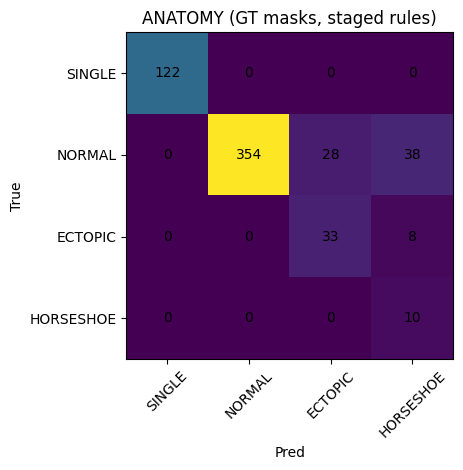

ANATOMY Stage-1 macro F1 (count==2): 0.7609 | per-class: [0.9147, 0.6071]


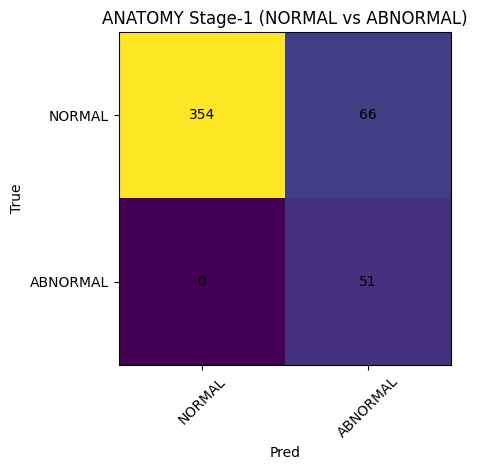

ANATOMY Stage-2 macro F1 (abnormal only): 0.8031 | per-class: [0.8919, 0.7143]


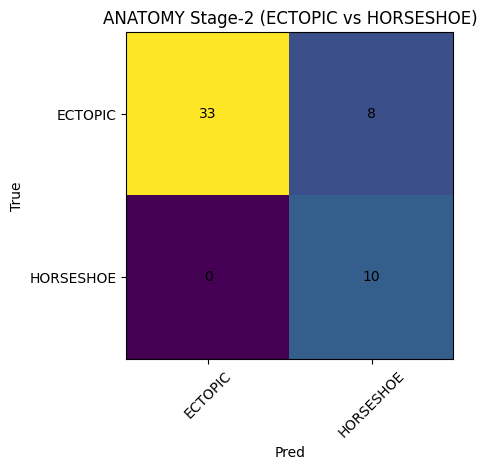

In [12]:
# CELL 23.7 - ANATOMY head (GT masks only, staged rules + classifier-like Stage-2)

import numpy as np

ANAT_LABELS = ["SINGLE", "NORMAL", "ECTOPIC", "HORSESHOE"]
ANAT_TO_I = {s: i for i, s in enumerate(ANAT_LABELS)}
ANAT1_LABELS = ["NORMAL", "ABNORMAL"]
ANAT2_LABELS = ["ECTOPIC", "HORSESHOE"]

# Stage-1 geometry thresholds (same intent as POSITION).
SIDE_BY_SIDE_DX_FRAC = 0.55
SAME_AXIS_DY_FRAC = 0.35
CLEAR_GAP_FRAC = 0.10
CLEAR_GAP_PIX = 6
ANAT1_THRESHOLD = 0.50


def _patient_label_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
    return df.iloc[int(ri)]


def _norm_anat_label(x):
    s = norm_str(x)
    if s == "HORSHOE":
        s = "HORSESHOE"
    return s


def _mask_stats(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0 = int(xs.min()); x1 = int(xs.max())
    y0 = int(ys.min()); y1 = int(ys.max())
    area = int(xs.size)
    cx = float(xs.mean()); cy = float(ys.mean())
    w = float(x1 - x0 + 1); h = float(y1 - y0 + 1)
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1, "area": area, "cx": cx, "cy": cy, "w": w, "h": h}


def _view_pair_features(mL, mR):
    sL = _mask_stats(mL); sR = _mask_stats(mR)
    if sL is None or sR is None:
        return None

    a, b = (sL, sR) if sL["cx"] <= sR["cx"] else (sR, sL)

    dx = abs(a["cx"] - b["cx"])
    dy = abs(a["cy"] - b["cy"])
    mean_w = 0.5 * (a["w"] + b["w"])
    mean_h = 0.5 * (a["h"] + b["h"])

    x_gap = max(0.0, float(b["x0"] - a["x1"] - 1))
    x_overlap = max(0.0, float(min(a["x1"], b["x1"]) - max(a["x0"], b["x0"]) + 1))

    areaL = float(sL["area"]); areaR = float(sR["area"])
    area_sum = max(areaL + areaR, 1.0)
    area_imb = abs(areaL - areaR) / area_sum

    inter = float(((mL > 0) & (mR > 0)).sum())
    overlap_frac = inter / max(min(areaL, areaR), 1.0)

    union = ((mL > 0) | (mR > 0)).astype(np.uint8)
    union_area = float(union.sum())

    mid_x = int(round(0.5 * (a["cx"] + b["cx"])))
    band_half = int(round(0.25 * max(mean_w, 1.0)))
    x0 = max(0, mid_x - band_half)
    x1 = min(IMG_SIZE, mid_x + band_half + 1)
    bridge_pixels = float(union[:, x0:x1].sum())
    bridge_frac = bridge_pixels / max(union_area, 1.0)

    gap_frac = x_gap / max(mean_w, 1.0)
    dy_frac = dy / max(mean_h, 1.0)

    side_by_side = (dx >= SIDE_BY_SIDE_DX_FRAC * max(mean_w, 1.0)) and (dx >= dy)
    same_axis = dy <= SAME_AXIS_DY_FRAC * max(mean_h, 1.0)
    clear_gap = x_gap >= max(CLEAR_GAP_PIX, CLEAR_GAP_FRAC * max(mean_w, 1.0))

    normal_stage1 = bool(side_by_side and same_axis and clear_gap and x_overlap <= 0.0)

    # Classifier-like fused cue: not a hard rule, just a soft feature.
    fused_like = float((overlap_frac > 0.02) or (bridge_frac > 0.04))

    return {
        "normal_stage1": normal_stage1,
        "overlap_frac": float(overlap_frac),
        "bridge_frac": float(bridge_frac),
        "gap_frac": float(gap_frac),
        "dy_frac": float(dy_frac),
        "area_imb": float(area_imb),
        "fused_like": float(fused_like),
    }


def _derived_count(pid):
    Lp, Rp = patient_presence(pid)
    return int(Lp + Rp)


def anatomy_pred_for_pid(pid):
    dcount = _derived_count(pid)

    # Stage-0 routing rule.
    if dcount <= 1:
        return "SINGLE", {"stage0": "count<=1", "dcount": dcount}

    rows = patient_views(pid)
    w = W_POS_ANAT1

    # Stage-1: NORMAL vs ABNORMAL.
    num = 0.0; den = 0.0
    feats_by_view = []
    for vi, ri in enumerate(rows):
        if ri is None:
            continue
        _, mL, mR = _get_row_view_tensor(ri)
        feats = _view_pair_features(mL, mR)
        if feats is None:
            continue
        num += float(w[vi]) * float(feats["normal_stage1"])
        den += float(w[vi])
        feats_by_view.append((vi, feats))

    normal_score = (num / den) if den > 0 else 0.0
    stage1 = "NORMAL" if normal_score >= ANAT1_THRESHOLD else "ABNORMAL"

    if stage1 == "NORMAL":
        return "NORMAL", {"stage1": stage1, "normal_score": float(normal_score), "dcount": dcount}

    # Stage-2: ECTOPIC vs HORSESHOE (soft cues; no single overlap rule).
    horse_num = 0.0; ecto_num = 0.0; den2 = 0.0
    for vi, feats in feats_by_view:
        wi = float(w[vi])
        # Multi-cue scoring: overlap/bridge help horseshoe, while large offset/gap/imbalance help ectopic.
        horse_view = (
            1.8 * feats["overlap_frac"] +
            1.4 * feats["bridge_frac"] +
            0.6 * feats["fused_like"] -
            0.9 * feats["dy_frac"] -
            0.7 * feats["gap_frac"] -
            0.4 * feats["area_imb"]
        )
        ecto_view = (
            1.4 * feats["dy_frac"] +
            1.0 * feats["gap_frac"] +
            0.6 * feats["area_imb"] -
            0.6 * feats["overlap_frac"] -
            0.5 * feats["bridge_frac"]
        )
        horse_num += wi * float(horse_view)
        ecto_num += wi * float(ecto_view)
        den2 += wi

    horse_score = (horse_num / den2) if den2 > 0 else 0.0
    ecto_score = (ecto_num / den2) if den2 > 0 else 0.0

    pred2 = "HORSESHOE" if horse_score >= ecto_score else "ECTOPIC"
    return pred2, {
        "stage1": stage1,
        "normal_score": float(normal_score),
        "horse_score": float(horse_score),
        "ecto_score": float(ecto_score),
        "dcount": dcount,
    }


anat_true = []
anat_pred = []

anat1_true = []
anat1_pred = []

anat2_true = []
anat2_pred = []

for pid in patients:
    row = _patient_label_row(pid)
    gt_full = _norm_anat_label(row.get(COL_ANAT, ""))
    if gt_full not in ANAT_TO_I:
        continue

    pred_full, info = anatomy_pred_for_pid(pid)
    anat_true.append(ANAT_TO_I[gt_full])
    anat_pred.append(ANAT_TO_I[pred_full])

    dcount = int(info.get("dcount", 0))
    if dcount == 2 and gt_full in ("NORMAL", "ECTOPIC", "HORSESHOE"):
        gt_stage1 = "NORMAL" if gt_full == "NORMAL" else "ABNORMAL"
        pred_stage1 = "NORMAL" if pred_full == "NORMAL" else "ABNORMAL"
        anat1_true.append(ANAT1_LABELS.index(gt_stage1))
        anat1_pred.append(ANAT1_LABELS.index(pred_stage1))

        if gt_full in ("ECTOPIC", "HORSESHOE") and pred_stage1 == "ABNORMAL":
            anat2_true.append(ANAT2_LABELS.index(gt_full))
            anat2_pred.append(ANAT2_LABELS.index(pred_full))

print("ANATOMY samples (all):", len(anat_true))
cm_anat = confusion_matrix_np(anat_true, anat_pred, n_classes=len(ANAT_LABELS))
f1s_anat, f1m_anat = f1_macro_from_cm(cm_anat)
print("ANATOMY macro F1 (all):", round(f1m_anat, 4), "| per-class:", [round(x, 4) for x in f1s_anat])
plot_cm(cm_anat, "ANATOMY (GT masks, staged rules)", ANAT_LABELS)

if len(anat1_true):
    cm_anat1 = confusion_matrix_np(anat1_true, anat1_pred, n_classes=len(ANAT1_LABELS))
    f1s_anat1, f1m_anat1 = f1_macro_from_cm(cm_anat1)
    print("ANATOMY Stage-1 macro F1 (count==2):", round(f1m_anat1, 4), "| per-class:", [round(x, 4) for x in f1s_anat1])
    plot_cm(cm_anat1, "ANATOMY Stage-1 (NORMAL vs ABNORMAL)", ANAT1_LABELS)

if len(anat2_true):
    cm_anat2 = confusion_matrix_np(anat2_true, anat2_pred, n_classes=len(ANAT2_LABELS))
    f1s_anat2, f1m_anat2 = f1_macro_from_cm(cm_anat2)
    print("ANATOMY Stage-2 macro F1 (abnormal only):", round(f1m_anat2, 4), "| per-class:", [round(x, 4) for x in f1s_anat2])
    plot_cm(cm_anat2, "ANATOMY Stage-2 (ECTOPIC vs HORSESHOE)", ANAT2_LABELS)


In [13]:
# CELL 23.5 - Post-seg model architecture (ConvNeXt-Base, 4-ch, 3-view weighted fusion)

import torch
import torch.nn as nn
import timm

class ConvNeXtHead(nn.Module):
    """
    Post-seg head:
    - backbone: convnext_base, pretrained
    - input: 4-channel images (I, I*mask, mask, I*(1-mask))
    - view fusion: weighted sum across 3 views (P/LPO/RPO)
    - extra features: configurable feat_dim appended before FC
    """
    def __init__(self, n_classes, feat_dim=3):
        super().__init__()
        self.feat_dim = int(feat_dim)
        self.backbone = timm.create_model(
            "convnext_base",
            pretrained=True,
            in_chans=4,
            num_classes=0,
            global_pool="avg"
        )
        self.fc = nn.Sequential(
            nn.Linear(self.backbone.num_features + self.feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, n_classes)
        )

    def forward(self, x3v, feat, w):
        # x3v: [B,3,4,H,W], feat: [B,feat_dim], w: [3]
        logits = 0
        for vi in range(3):
            f = self.backbone(x3v[:, vi])
            f = torch.cat([f, feat], dim=1)
            lv = self.fc(f)
            logits = logits + float(w[vi]) * lv
        return logits


POSITION valid train (count==2): 380
POSITION valid val   (count==2): 42
POSITION valid test  (count==2): 49
POSITION oversampled train ids: 639


  0%|          | 0/107 [00:00<?, ?it/s]c:\Users\muhta\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\adamw.py:529: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)
                                                 

[POSITION] ep 01 | train loss 0.1842 f1m 0.9322 n 639 | val loss 0.0063 f1m 1.0000 n 42 | 979.0s


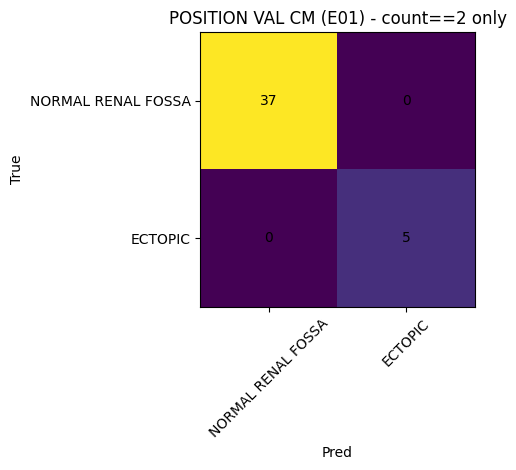

POSITION saved best: G:\Tasfique's\best_POSITION_gtmask.pt | best: 1.0


KeyboardInterrupt: 

In [14]:
# CELL 23.8 - POSITION head training (GT masks, gated on derived count==2)

import math
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

POS2 = ["NORMAL RENAL FOSSA", "ECTOPIC"]
POS_TO_I = {s: i for i, s in enumerate(POS2)}


def _pos_patient_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
    return df.iloc[int(ri)]


def _pos_norm_label(x):
    return norm_str(x)


def _pos_mask_stats(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0 = int(xs.min()); x1 = int(xs.max())
    y0 = int(ys.min()); y1 = int(ys.max())
    cx = float(xs.mean()); cy = float(ys.mean())
    w = float(x1 - x0 + 1); h = float(y1 - y0 + 1)
    area = float(xs.size)
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1, "cx": cx, "cy": cy, "w": w, "h": h, "area": area}


def _pos_pair_geom(mL, mR):
    sL = _pos_mask_stats(mL); sR = _pos_mask_stats(mR)
    if sL is None or sR is None:
        return None

    a, b = (sL, sR) if sL["cx"] <= sR["cx"] else (sR, sL)
    dx = abs(a["cx"] - b["cx"])
    dy = abs(a["cy"] - b["cy"])
    mean_w = 0.5 * (a["w"] + b["w"])
    mean_h = 0.5 * (a["h"] + b["h"])
    gap = max(0.0, float(b["x0"] - a["x1"] - 1))

    dx_norm = dx / max(mean_w, 1.0)
    dy_norm = dy / max(mean_h, 1.0)
    gap_norm = gap / max(mean_w, 1.0)
    return np.array([dx_norm, dy_norm, gap_norm], dtype=np.float32)


def _pos_feat_for_pid(pid):
    rows = patient_views(pid)
    w = W_POS_ANAT1.astype(np.float32)
    acc = np.zeros((3,), dtype=np.float32)
    den = 0.0
    for vi, ri in enumerate(rows):
        if ri is None:
            continue
        _, mL, mR = _get_row_view_tensor(ri)
        f = _pos_pair_geom(mL, mR)
        if f is None:
            continue
        acc += float(w[vi]) * f
        den += float(w[vi])
    return (acc / den) if den > 0 else acc


def _pos_derived_count(pid):
    Lp, Rp = patient_presence(pid)
    return int(Lp + Rp)


def _pos_valid_label_for_pid(pid):
    row = _pos_patient_row(pid)
    gt = _pos_norm_label(row.get(COL_POS, ""))
    if gt not in POS_TO_I:
        return None
    if _pos_derived_count(pid) != 2:
        return None
    return gt


def _count_pos_valid(pids):
    n = 0
    for pid in pids:
        if _pos_valid_label_for_pid(pid) is not None:
            n += 1
    return n


class PositionDataset(Dataset):
    def __init__(self, pids):
        self.pids = list(pids)

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[int(idx)]
        rows = patient_views(pid)

        X = np.zeros((3, 4, IMG_SIZE, IMG_SIZE), dtype=np.float32)
        for vi, ri in enumerate(rows):
            if ri is None:
                continue
            I, mL, mR = _get_row_view_tensor(ri)
            X[vi] = build_input4(I, mL, mR, mode="GEN")

        feat = _pos_feat_for_pid(pid).astype(np.float32)

        gt = _pos_valid_label_for_pid(pid)
        if gt is None:
            y = -1; valid = 0
        else:
            y = POS_TO_I[gt]; valid = 1

        return {
            "pid": pid,
            "x": torch.from_numpy(X),
            "feat": torch.from_numpy(feat),
            "y": torch.tensor(int(y), dtype=torch.long),
            "valid": torch.tensor(int(valid), dtype=torch.long),
            "dcount": torch.tensor(int(_pos_derived_count(pid)), dtype=torch.long),
        }


def make_position_train_pids():
    mult_map = OVERSAMPLE.get("POSITION", {})
    out = []
    for pid in train_p:
        gt = _pos_valid_label_for_pid(pid)
        if gt is None:
            continue
        mult = int(mult_map.get(gt, 1))
        mult = max(mult, 1)
        for _ in range(mult):
            out.append(pid)
    return out


def _run_pos_epoch(model, loader, opt=None):
    is_train = opt is not None
    model.train(is_train)
    ce = nn.CrossEntropyLoss()

    total_loss = 0.0
    n = 0
    y_true = []
    y_pred = []

    w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)

    for batch in tqdm(loader, leave=False):
        valid = batch["valid"].to(DEVICE).bool()
        if not bool(valid.any()):
            continue

        x = batch["x"].to(DEVICE)[valid]
        feat = batch["feat"].to(DEVICE)[valid]
        y = batch["y"].to(DEVICE)[valid]

        with torch.set_grad_enabled(is_train):
            logits = model(x, feat, w)
            loss = ce(logits, y)

        if is_train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        bs = int(y.size(0))
        total_loss += float(loss.item()) * bs
        n += bs

        y_true.extend(y.detach().cpu().tolist())
        y_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

    if n == 0:
        cm = np.zeros((len(POS2), len(POS2)), dtype=np.int64)
        return {"loss": float("nan"), "f1m": 0.0, "cm": cm, "n": 0}

    cm = confusion_matrix_np(y_true, y_pred, n_classes=len(POS2))
    f1s, f1m = f1_macro_from_cm(cm)
    return {"loss": total_loss / max(n, 1), "f1m": float(f1m), "cm": cm, "f1s": f1s, "n": n}


def position_infer_pid(model, pid):
    dcount = _pos_derived_count(pid)
    if dcount <= 1:
        return "NORMAL RENAL FOSSA", {"rule": "count<=1", "dcount": dcount}

    sample = PositionDataset([pid])[0]
    with torch.no_grad():
        x = sample["x"].unsqueeze(0).to(DEVICE)
        feat = sample["feat"].unsqueeze(0).to(DEVICE)
        w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)
        logits = model(x, feat, w)
        pred_i = int(torch.argmax(logits, dim=1).item())
    return POS2[pred_i], {"dcount": dcount}


pos_tr_ids = make_position_train_pids()
pos_val_ids = list(val_p)
pos_test_ids = list(test_p)

print("POSITION valid train (count==2):", _count_pos_valid(train_p))
print("POSITION valid val   (count==2):", _count_pos_valid(val_p))
print("POSITION valid test  (count==2):", _count_pos_valid(test_p))
print("POSITION oversampled train ids:", len(pos_tr_ids))

pos_tr_ds = PositionDataset(pos_tr_ids)
pos_va_ds = PositionDataset(pos_val_ids)

pos_tr_loader = DataLoader(pos_tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
pos_va_loader = DataLoader(pos_va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

pos_model = ConvNeXtHead(n_classes=len(POS2)).to(DEVICE)
pos_opt = torch.optim.AdamW(pos_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_path = BASE_DIR / "best_POSITION_gtmask.pt"
# Safe init so reload always works even if val has 0 eligible samples.
torch.save({"model": pos_model.state_dict(), "epoch": 0, "best": -1.0}, best_path)
best = -1.0
bad = 0

for ep in range(1, int(EPOCHS) + 1):
    t0 = time.time()
    tr_m = _run_pos_epoch(pos_model, pos_tr_loader, opt=pos_opt)
    va_m = _run_pos_epoch(pos_model, pos_va_loader, opt=None)

    if va_m["n"] == 0:
        bad += 1
        print(
            f"[POSITION] ep {ep:02d} | train loss {tr_m['loss']:.4f} f1m {tr_m['f1m']:.4f} n {tr_m['n']}"
            f" | VAL has 0 eligible samples (count==2) | bad {bad}/{PATIENCE} | {time.time()-t0:.1f}s"
        )
        if EARLY_STOP_ON and bad >= int(PATIENCE):
            print("POSITION early stop (no val samples) at ep", ep)
            break
        continue

    metric = float(va_m["f1m"])

    print(
        f"[POSITION] ep {ep:02d} | train loss {tr_m['loss']:.4f} f1m {tr_m['f1m']:.4f} n {tr_m['n']}"
        f" | val loss {va_m['loss']:.4f} f1m {va_m['f1m']:.4f} n {va_m['n']} | {time.time()-t0:.1f}s"
    )
    plot_cm(va_m["cm"], f"POSITION VAL CM (E{ep:02d}) - count==2 only", POS2)

    if metric > best + float(MIN_DELTA):
        best = metric
        bad = 0
        torch.save({"model": pos_model.state_dict(), "epoch": ep, "best": best}, best_path)
        print("POSITION saved best:", best_path, "| best:", best)
    else:
        bad += 1
        print("POSITION no improve. bad:", bad, "/", PATIENCE)
        if EARLY_STOP_ON and bad >= int(PATIENCE):
            print("POSITION early stop at ep", ep)
            break

ck = torch.load(best_path, map_location=DEVICE)
pos_model.load_state_dict(ck["model"])
pos_model.eval()
print("POSITION reloaded best:", best_path, "| epoch:", ck.get("epoch"), "| best:", ck.get("best"))


def eval_position_with_gate(model, pids):
    y_true = []
    y_pred = []
    y_true_c2 = []
    y_pred_c2 = []

    for pid in pids:
        row = _pos_patient_row(pid)
        gt = _pos_norm_label(row.get(COL_POS, ""))
        if gt not in POS_TO_I:
            continue

        dcount = _pos_derived_count(pid)
        if dcount <= 1:
            pred = "NORMAL RENAL FOSSA"
        else:
            pred, _ = position_infer_pid(model, pid)

        y_true.append(POS_TO_I[gt])
        y_pred.append(POS_TO_I[pred])

        if dcount == 2:
            y_true_c2.append(POS_TO_I[gt])
            y_pred_c2.append(POS_TO_I[pred])

    cm_all = confusion_matrix_np(y_true, y_pred, n_classes=len(POS2))
    f1s_all, f1m_all = f1_macro_from_cm(cm_all)
    print("POSITION macro F1 (with gating):", round(f1m_all, 4), "| per-class:", [round(x, 4) for x in f1s_all])
    plot_cm(cm_all, "POSITION (GT masks, trained + gating)", POS2)

    if len(y_true_c2):
        cm_c2 = confusion_matrix_np(y_true_c2, y_pred_c2, n_classes=len(POS2))
        f1s_c2, f1m_c2 = f1_macro_from_cm(cm_c2)
        print("POSITION macro F1 (count==2 only):", round(f1m_c2, 4), "| per-class:", [round(x, 4) for x in f1s_c2])
        plot_cm(cm_c2, "POSITION (count==2 only)", POS2)


eval_position_with_gate(pos_model, pos_test_ids)


ANAT1 valid train (count==2): 380
ANAT1 valid val   (count==2): 42
ANAT1 oversampled train ids: 639


[ANAT1] ep 01 | train loss 0.2903 f1m 0.8725 n 639 | val loss 0.0061 f1m 1.0000 n 42 | 898.6s


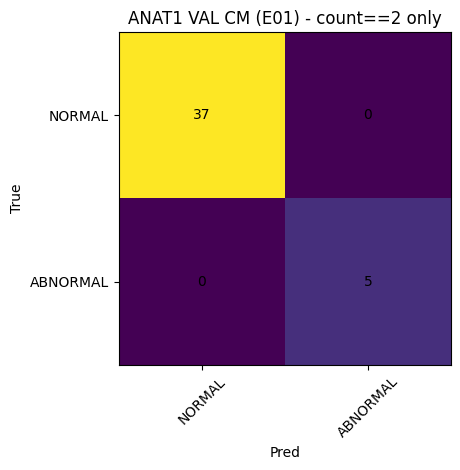

ANAT1 saved best: G:\Tasfique's\best_ANAT1_gtmask.pt | best: 1.0


[ANAT1] ep 02 | train loss 0.0430 f1m 0.9890 n 639 | val loss 0.0048 f1m 1.0000 n 42 | 917.8s


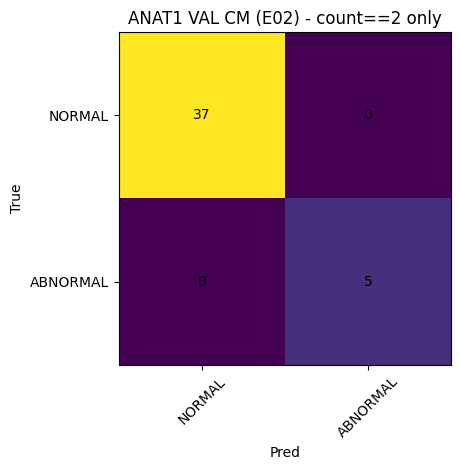

ANAT1 no improve. bad: 1 / 7


[ANAT1] ep 03 | train loss 0.0124 f1m 0.9969 n 639 | val loss 0.0068 f1m 1.0000 n 42 | 901.0s


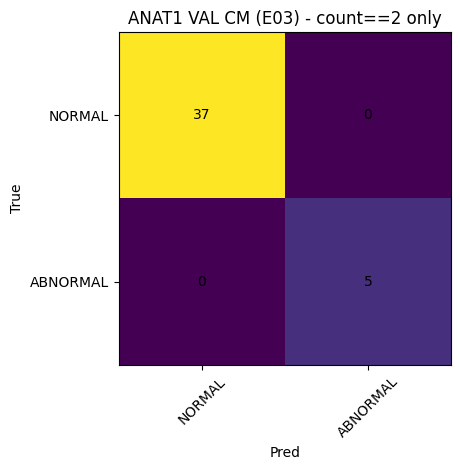

ANAT1 no improve. bad: 2 / 7


[ANAT1] ep 04 | train loss 0.1288 f1m 0.9606 n 639 | val loss 0.0353 f1m 1.0000 n 42 | 905.8s


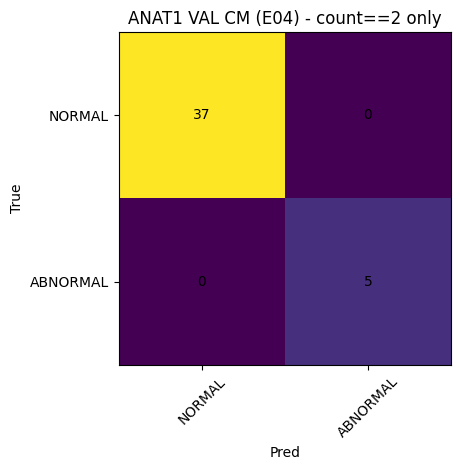

ANAT1 no improve. bad: 3 / 7


[ANAT1] ep 05 | train loss 0.1033 f1m 0.9716 n 639 | val loss 0.0034 f1m 1.0000 n 42 | 893.6s


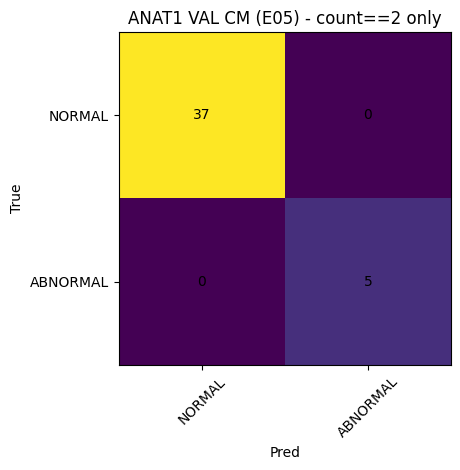

ANAT1 no improve. bad: 4 / 7


[ANAT1] ep 06 | train loss 0.0011 f1m 1.0000 n 639 | val loss 0.0007 f1m 1.0000 n 42 | 896.5s


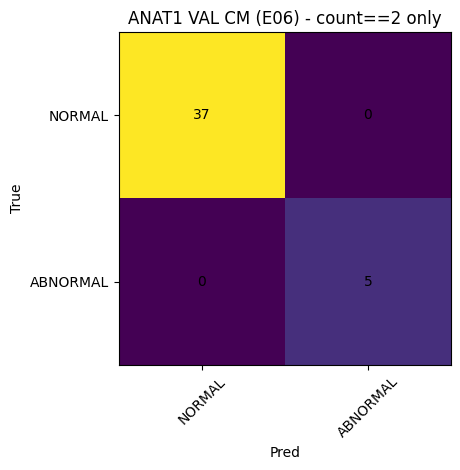

ANAT1 no improve. bad: 5 / 7


[ANAT1] ep 07 | train loss 0.0004 f1m 1.0000 n 639 | val loss 0.0004 f1m 1.0000 n 42 | 901.8s


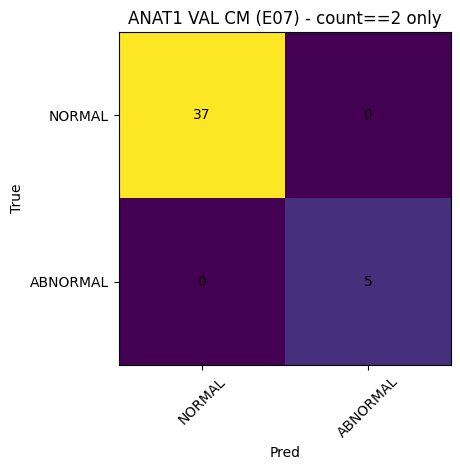

ANAT1 no improve. bad: 6 / 7


[ANAT1] ep 08 | train loss 0.0002 f1m 1.0000 n 639 | val loss 0.0002 f1m 1.0000 n 42 | 873.9s


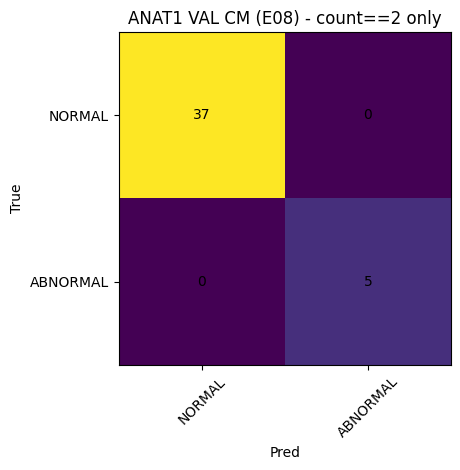

C:\Users\muhta\AppData\Local\Temp\ipykernel_24212\2639415278.py:340: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(best_path, map_location=DEVICE)


ANAT1 no improve. bad: 7 / 7
ANAT1 early stop at ep 8
ANAT1 reloaded best: G:\Tasfique's\best_ANAT1_gtmask.pt | epoch: 1 | best: 1.0
ANAT2 valid train (count==2): 37
ANAT2 valid val   (count==2): 5
ANAT2 oversampled train ids: 355


[ANAT2] ep 01 | train loss 0.1356 f1m 0.9465 n 355 | val loss 1.0647 f1m 0.7619 n 5 | 489.5s


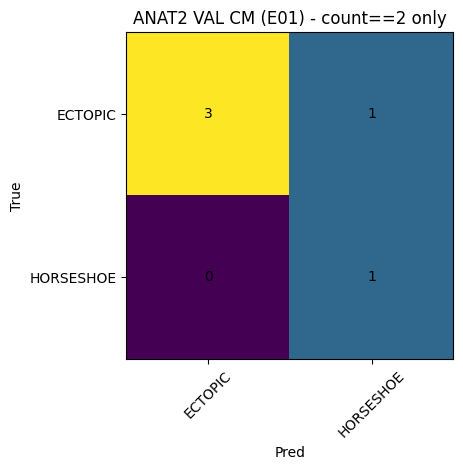

ANAT2 saved best: G:\Tasfique's\best_ANAT2_gtmask.pt | best: 0.7619047619047619


[ANAT2] ep 02 | train loss 0.0003 f1m 1.0000 n 355 | val loss 1.6861 f1m 0.7619 n 5 | 503.5s


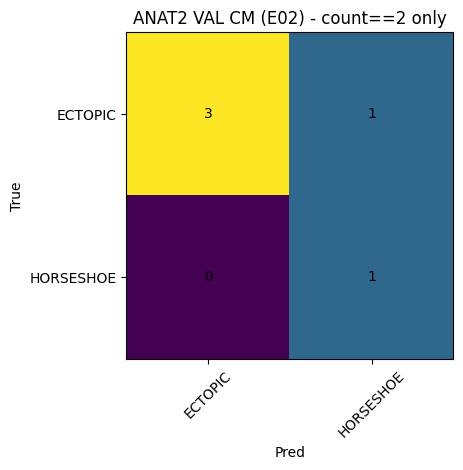

ANAT2 no improve. bad: 1 / 7


[ANAT2] ep 03 | train loss 0.0001 f1m 1.0000 n 355 | val loss 1.7376 f1m 0.7619 n 5 | 491.8s


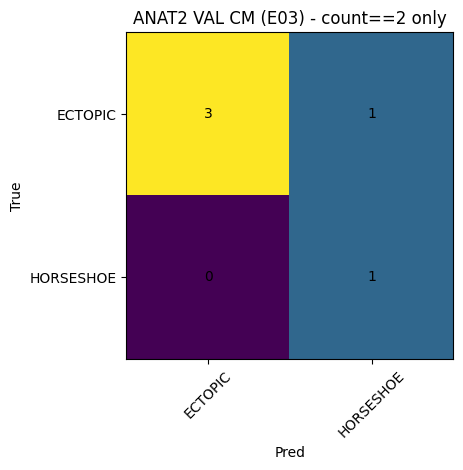

ANAT2 no improve. bad: 2 / 7


[ANAT2] ep 04 | train loss 0.0001 f1m 1.0000 n 355 | val loss 1.7841 f1m 0.7619 n 5 | 505.1s


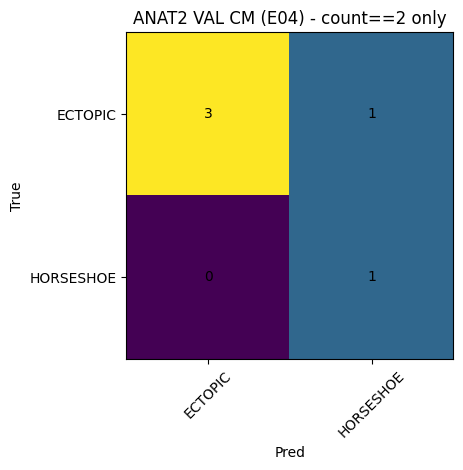

ANAT2 no improve. bad: 3 / 7


[ANAT2] ep 05 | train loss 0.0001 f1m 1.0000 n 355 | val loss 1.8296 f1m 0.7619 n 5 | 504.8s


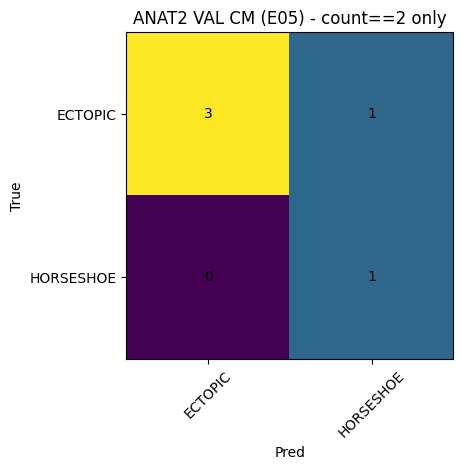

ANAT2 no improve. bad: 4 / 7


[ANAT2] ep 06 | train loss 0.0001 f1m 1.0000 n 355 | val loss 1.8717 f1m 0.7619 n 5 | 510.4s


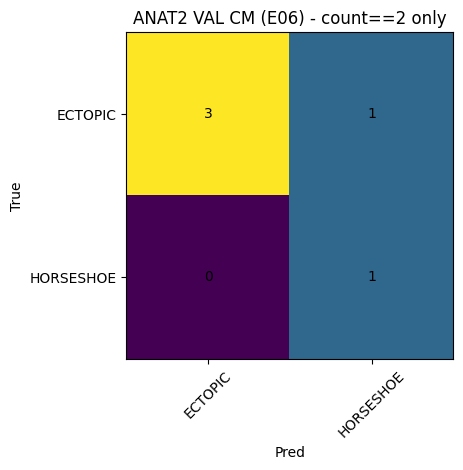

ANAT2 no improve. bad: 5 / 7


[ANAT2] ep 07 | train loss 0.0000 f1m 1.0000 n 355 | val loss 1.9101 f1m 0.7619 n 5 | 519.7s


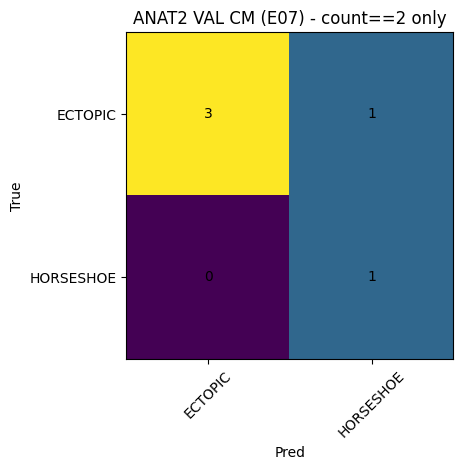

ANAT2 no improve. bad: 6 / 7


[ANAT2] ep 08 | train loss 0.0000 f1m 1.0000 n 355 | val loss 1.9448 f1m 0.7619 n 5 | 513.8s


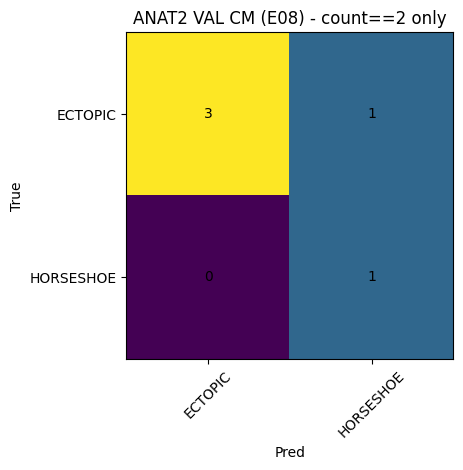

C:\Users\muhta\AppData\Local\Temp\ipykernel_24212\2639415278.py:340: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(best_path, map_location=DEVICE)


ANAT2 no improve. bad: 7 / 7
ANAT2 early stop at ep 8
ANAT2 reloaded best: G:\Tasfique's\best_ANAT2_gtmask.pt | epoch: 1 | best: 0.7619047619047619
ANATOMY macro F1 (with gating): 0.933 | per-class: [1.0, 0.963, 0.7692, 1.0]


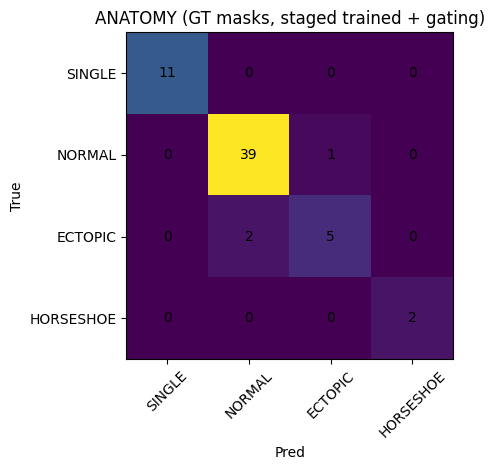

ANATOMY Stage-1 macro F1 (count==2): 0.8932 | per-class: [0.963, 0.8235]


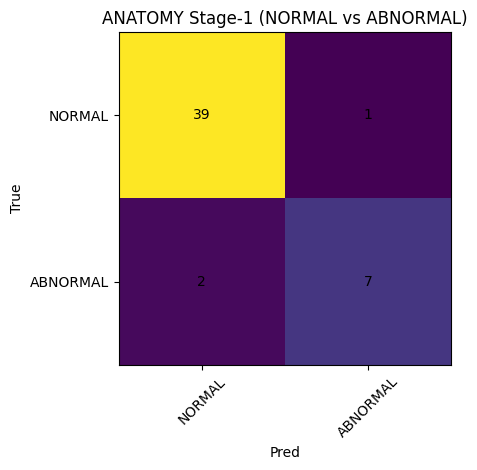

ANATOMY Stage-2 macro F1 (abnormal only): 1.0 | per-class: [1.0, 1.0]


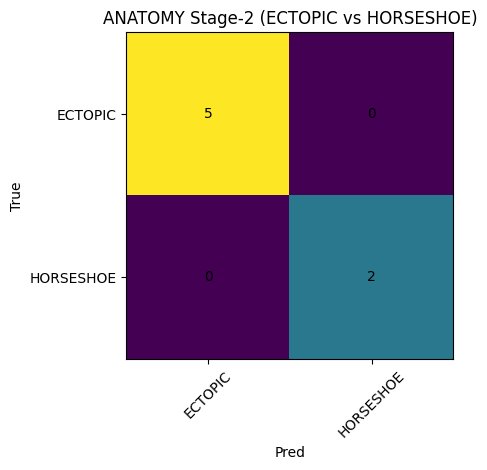

In [15]:
# CELL 23.9 - ANATOMY staged training (GT masks, gated on derived count==2, geometry features)

import math
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

ANAT_LABELS = ["SINGLE", "NORMAL", "ECTOPIC", "HORSESHOE"]
ANAT_TO_I = {s: i for i, s in enumerate(ANAT_LABELS)}
ANAT1_LABELS = ["NORMAL", "ABNORMAL"]
ANAT2_LABELS = ["ECTOPIC", "HORSESHOE"]

ANAT_FEAT_DIM = 7


def _anat_patient_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])   
    return df.iloc[int(ri)]


def _anat_norm_label(x):
    s = norm_str(x)
    if s == "HORSHOE":
        s = "HORSESHOE"
    return s


def _anat_derived_count(pid):
    Lp, Rp = patient_presence(pid)
    return int(Lp + Rp)


def _anat_mask_stats(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0 = int(xs.min()); x1 = int(xs.max())
    y0 = int(ys.min()); y1 = int(ys.max())
    cx = float(xs.mean()); cy = float(ys.mean())
    w = float(x1 - x0 + 1); h = float(y1 - y0 + 1)
    area = float(xs.size)
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1, "cx": cx, "cy": cy, "w": w, "h": h, "area": area}


def _anat_geom_features_from_masks(mL, mR):
    sL = _anat_mask_stats(mL); sR = _anat_mask_stats(mR)
    if sL is None or sR is None:
        return None

    # Order kidneys left-to-right by centroid x to make gap/bridge consistent.
    a, b = (sL, sR) if sL["cx"] <= sR["cx"] else (sR, sL)

    dx = abs(a["cx"] - b["cx"])
    dy = abs(a["cy"] - b["cy"])
    mean_w = 0.5 * (a["w"] + b["w"])
    mean_h = 0.5 * (a["h"] + b["h"])

    gap = max(0.0, float(b["x0"] - a["x1"] - 1))

    dx_norm = dx / max(mean_w, 1.0)
    dy_norm = dy / max(mean_h, 1.0)
    gap_norm = gap / max(mean_w, 1.0)

    areaL = float(sL["area"]); areaR = float(sR["area"])
    area_sum = max(areaL + areaR, 1.0)
    area_imb = abs(areaL - areaR) / area_sum

    inter = float(((mL > 0) & (mR > 0)).sum())
    overlap_frac = inter / max(min(areaL, areaR), 1.0)

    union = ((mL > 0) | (mR > 0)).astype(np.uint8)
    union_area = float(union.sum())

    mid_x = int(round(0.5 * (a["cx"] + b["cx"])))
    band_half = max(1, int(round(0.25 * max(mean_w, 1.0))))
    x0 = max(0, mid_x - band_half)
    x1 = min(IMG_SIZE, mid_x + band_half + 1)
    bridge_pixels = float(union[:, x0:x1].sum())
    bridge_frac = bridge_pixels / max(union_area, 1.0)

    # Soft fusion cue (not a hard rule): overlap/bridge can suggest horseshoe.
    fused_like = 1.0 if (overlap_frac > 0.02 or bridge_frac > 0.04) else 0.0

    return np.array(
        [dx_norm, dy_norm, gap_norm, overlap_frac, bridge_frac, area_imb, fused_like],
        dtype=np.float32,
    )


def _anat_weighted_fuse_view_feats(per_view_feats, w, view_valid):
    w = np.asarray(w, dtype=np.float32).reshape(-1)
    vv = np.asarray(view_valid, dtype=np.float32).reshape(-1)
    ww = w * vv
    den = float(ww.sum())
    if den <= 0:
        return np.zeros((per_view_feats.shape[1],), dtype=np.float32)
    return (per_view_feats * ww[:, None]).sum(axis=0) / den


def _anat_feat_for_pid(pid):
    rows = patient_views(pid)
    per_view_feats = np.zeros((3, ANAT_FEAT_DIM), dtype=np.float32)
    view_valid = np.zeros((3,), dtype=np.float32)

    for vi, ri in enumerate(rows):
        if ri is None:
            continue
        _, mL, mR = _get_row_view_tensor(ri)
        if int(mL.sum()) == 0 or int(mR.sum()) == 0:
            continue
        f = _anat_geom_features_from_masks(mL, mR)
        if f is None:
            continue
        per_view_feats[vi] = f
        view_valid[vi] = 1.0

    return _anat_weighted_fuse_view_feats(per_view_feats, W_POS_ANAT1, view_valid)


def _anat_stage1_label(full_label):
    if full_label == "NORMAL":
        return "NORMAL"
    if full_label in ("ECTOPIC", "HORSESHOE"):
        return "ABNORMAL"
    return None


def _anat_stage2_label(full_label):
    if full_label in ANAT2_LABELS:
        return full_label
    return None


def _anat_valid_label_for_pid(pid, stage):
    if _anat_derived_count(pid) != 2:
        return None
    row = _anat_patient_row(pid)
    full = _anat_norm_label(row.get(COL_ANAT, ""))
    if full not in ANAT_TO_I:
        return None
    if stage == "ANAT1":
        return _anat_stage1_label(full)
    if stage == "ANAT2":
        return _anat_stage2_label(full)
    return None


def _count_anat_valid(pids, stage):
    n = 0
    for pid in pids:
        if _anat_valid_label_for_pid(pid, stage) is not None:
            n += 1
    return n


class AnatomyStageDataset(Dataset):
    def __init__(self, pids, stage):
        self.pids = list(pids)
        self.stage = stage

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[int(idx)]
        rows = patient_views(pid)

        X = np.zeros((3, 4, IMG_SIZE, IMG_SIZE), dtype=np.float32)
        for vi, ri in enumerate(rows):
            if ri is None:
                continue
            I, mL, mR = _get_row_view_tensor(ri)
            X[vi] = build_input4(I, mL, mR, mode="GEN")

        feat = _anat_feat_for_pid(pid).astype(np.float32)

        lab = _anat_valid_label_for_pid(pid, self.stage)
        if lab is None:
            y = -1; valid = 0
        else:
            if self.stage == "ANAT1":
                y = ANAT1_LABELS.index(lab)
            else:
                y = ANAT2_LABELS.index(lab)
            valid = 1

        return {
            "pid": pid,
            "x": torch.from_numpy(X),
            "feat": torch.from_numpy(feat),
            "y": torch.tensor(int(y), dtype=torch.long),
            "valid": torch.tensor(int(valid), dtype=torch.long),
            "dcount": torch.tensor(int(_anat_derived_count(pid)), dtype=torch.long),
        }


def make_anat_train_pids(stage):
    out = []
    if stage == "ANAT1":
        mult_map = OVERSAMPLE.get("POSITION", {})
    else:
        mult_map = OVERSAMPLE.get("ANAT2", {})

    for pid in train_p:
        lab = _anat_valid_label_for_pid(pid, stage)
        if lab is None:
            continue

        if stage == "ANAT1":
            key = "NORMAL RENAL FOSSA" if lab == "NORMAL" else "ECTOPIC"
            mult = int(mult_map.get(key, 1))
        else:
            if lab == "HORSESHOE":
                if "HORSESHOE" in mult_map:
                    mult = int(mult_map.get("HORSESHOE", 1))
                elif "HORSHOE" in mult_map:
                    mult = int(mult_map.get("HORSHOE", 1))
                else:
                    mult = int(mult_map.get(lab, 1))
            else:
                mult = int(mult_map.get(lab, 1))

        mult = max(mult, 1)
        for _ in range(mult):
            out.append(pid)
    return out


def _run_anat_epoch(model, loader, stage, opt=None):
    is_train = opt is not None
    model.train(is_train)
    ce = nn.CrossEntropyLoss()

    total_loss = 0.0
    n = 0
    y_true = []
    y_pred = []

    w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)

    for batch in tqdm(loader, leave=False):
        valid = batch["valid"].to(DEVICE).bool()
        if not bool(valid.any()):
            continue

        x = batch["x"].to(DEVICE)[valid]
        feat = batch["feat"].to(DEVICE)[valid]
        y = batch["y"].to(DEVICE)[valid]

        with torch.set_grad_enabled(is_train):
            logits = model(x, feat, w)
            loss = ce(logits, y)

        if is_train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        bs = int(y.size(0))
        total_loss += float(loss.item()) * bs
        n += bs

        y_true.extend(y.detach().cpu().tolist())
        y_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

    n_classes = len(ANAT1_LABELS) if stage == "ANAT1" else len(ANAT2_LABELS)
    if n == 0:
        cm = np.zeros((n_classes, n_classes), dtype=np.int64)
        return {"loss": float("nan"), "f1m": -1.0, "cm": cm, "n": 0}

    cm = confusion_matrix_np(y_true, y_pred, n_classes=n_classes)
    f1s, f1m = f1_macro_from_cm(cm)
    return {"loss": total_loss / max(n, 1), "f1m": float(f1m), "cm": cm, "f1s": f1s, "n": n}


def _train_anat_stage(stage, class_names, best_name):
    tr_ids = make_anat_train_pids(stage)
    va_ids = list(val_p)

    print(f"{stage} valid train (count==2):", _count_anat_valid(train_p, stage))
    print(f"{stage} valid val   (count==2):", _count_anat_valid(val_p, stage))
    print(f"{stage} oversampled train ids:", len(tr_ids))

    tr_ds = AnatomyStageDataset(tr_ids, stage)
    va_ds = AnatomyStageDataset(va_ids, stage)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = ConvNeXtHead(n_classes=len(class_names), feat_dim=ANAT_FEAT_DIM).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_path = BASE_DIR / best_name

    # Safe init so reload always works even if val has 0 eligible samples.
    torch.save({"model": model.state_dict(), "epoch": 0, "best": -1.0}, best_path)
    best = -1.0
    bad = 0

    for ep in range(1, int(EPOCHS) + 1):
        t0 = time.time()
        tr_m = _run_anat_epoch(model, tr_loader, stage=stage, opt=opt)
        va_m = _run_anat_epoch(model, va_loader, stage=stage, opt=None)

        if va_m["n"] == 0:
            bad += 1
            print(
                f"[{stage}] ep {ep:02d} | train loss {tr_m['loss']:.4f} f1m {tr_m['f1m']:.4f} n {tr_m['n']}"
                f" | VAL has 0 eligible samples (count==2) | bad {bad}/{PATIENCE} | {time.time()-t0:.1f}s"
            )
            if EARLY_STOP_ON and bad >= int(PATIENCE):
                print(stage, "early stop (no val samples) at ep", ep)
                break
            continue

        metric = float(va_m["f1m"])

        print(
            f"[{stage}] ep {ep:02d} | train loss {tr_m['loss']:.4f} f1m {tr_m['f1m']:.4f} n {tr_m['n']}"
            f" | val loss {va_m['loss']:.4f} f1m {va_m['f1m']:.4f} n {va_m['n']} | {time.time()-t0:.1f}s"
        )
        plot_cm(va_m["cm"], f"{stage} VAL CM (E{ep:02d}) - count==2 only", class_names)

        if metric > best + float(MIN_DELTA):
            best = metric
            bad = 0
            torch.save({"model": model.state_dict(), "epoch": ep, "best": best}, best_path)
            print(stage, "saved best:", best_path, "| best:", best)
        else:
            bad += 1
            print(stage, "no improve. bad:", bad, "/", PATIENCE)
            if EARLY_STOP_ON and bad >= int(PATIENCE):
                print(stage, "early stop at ep", ep)
                break

    ck = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ck["model"])
    model.eval()
    print(stage, "reloaded best:", best_path, "| epoch:", ck.get("epoch"), "| best:", ck.get("best"))
    return model


def anat1_infer_pid(model, pid):
    sample = AnatomyStageDataset([pid], stage="ANAT1")[0]
    with torch.no_grad():
        x = sample["x"].unsqueeze(0).to(DEVICE)
        feat = sample["feat"].unsqueeze(0).to(DEVICE)
        w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)
        logits = model(x, feat, w)
        pred_i = int(torch.argmax(logits, dim=1).item())
    return ANAT1_LABELS[pred_i]


def anat2_infer_pid(model, pid):
    sample = AnatomyStageDataset([pid], stage="ANAT2")[0]
    with torch.no_grad():
        x = sample["x"].unsqueeze(0).to(DEVICE)
        feat = sample["feat"].unsqueeze(0).to(DEVICE)
        w = torch.tensor(W_POS_ANAT1, dtype=torch.float32, device=DEVICE)
        logits = model(x, feat, w)
        pred_i = int(torch.argmax(logits, dim=1).item())
    return ANAT2_LABELS[pred_i]


anat1_model = _train_anat_stage("ANAT1", ANAT1_LABELS, "best_ANAT1_gtmask.pt")
anat2_model = _train_anat_stage("ANAT2", ANAT2_LABELS, "best_ANAT2_gtmask.pt")


def anatomy_infer_with_gate(pid):
    dcount = _anat_derived_count(pid)
    if dcount <= 1:
        return "SINGLE", {"rule": "count<=1", "dcount": dcount}

    s1 = anat1_infer_pid(anat1_model, pid)
    if s1 == "NORMAL":
        return "NORMAL", {"stage1": s1, "dcount": dcount}

    s2 = anat2_infer_pid(anat2_model, pid)
    return s2, {"stage1": s1, "stage2": s2, "dcount": dcount}


def eval_anatomy_with_gate(pids):
    y_true = []
    y_pred = []

    y1_true = []
    y1_pred = []

    y2_true = []
    y2_pred = []

    for pid in pids:
        row = _anat_patient_row(pid)
        gt_full = _anat_norm_label(row.get(COL_ANAT, ""))
        if gt_full not in ANAT_TO_I:
            continue

        pred_full, info = anatomy_infer_with_gate(pid)
        y_true.append(ANAT_TO_I[gt_full])
        y_pred.append(ANAT_TO_I[pred_full])

        dcount = _anat_derived_count(pid)
        if dcount == 2 and gt_full in ("NORMAL", "ECTOPIC", "HORSESHOE"):
            gt1 = _anat_stage1_label(gt_full)
            pr1 = "NORMAL" if pred_full == "NORMAL" else "ABNORMAL"
            y1_true.append(ANAT1_LABELS.index(gt1))
            y1_pred.append(ANAT1_LABELS.index(pr1))

            if gt_full in ANAT2_LABELS and pr1 == "ABNORMAL":
                y2_true.append(ANAT2_LABELS.index(gt_full))
                y2_pred.append(ANAT2_LABELS.index(pred_full))

    cm_all = confusion_matrix_np(y_true, y_pred, n_classes=len(ANAT_LABELS))
    f1s_all, f1m_all = f1_macro_from_cm(cm_all)
    print("ANATOMY macro F1 (with gating):", round(f1m_all, 4), "| per-class:", [round(x, 4) for x in f1s_all])
    plot_cm(cm_all, "ANATOMY (GT masks, staged trained + gating)", ANAT_LABELS)

    if len(y1_true):
        cm1 = confusion_matrix_np(y1_true, y1_pred, n_classes=len(ANAT1_LABELS))
        f1s1, f1m1 = f1_macro_from_cm(cm1)
        print("ANATOMY Stage-1 macro F1 (count==2):", round(f1m1, 4), "| per-class:", [round(x, 4) for x in f1s1])
        plot_cm(cm1, "ANATOMY Stage-1 (NORMAL vs ABNORMAL)", ANAT1_LABELS)

    if len(y2_true):
        cm2 = confusion_matrix_np(y2_true, y2_pred, n_classes=len(ANAT2_LABELS))
        f1s2, f1m2 = f1_macro_from_cm(cm2)
        print("ANATOMY Stage-2 macro F1 (abnormal only):", round(f1m2, 4), "| per-class:", [round(x, 4) for x in f1s2])
        plot_cm(cm2, "ANATOMY Stage-2 (ECTOPIC vs HORSESHOE)", ANAT2_LABELS)


eval_anatomy_with_gate(test_p)


DEVICE (enforced): privateuseone:0

TRAIN HEAD: SIZE_L | classes: ['SMALLER', 'NORMAL', 'BIGGER'] | view weights: [0.75, 0.125, 0.125]
Batch size: 1 | AMP: False | Accum: 1 | Backbone: convnext_tiny
Valid counts | train: 421 | val: 46 | test: 56
Feature dim: 11 | oversampled train ids: 694
Raw class counts: [53, 330, 38]
Class weights: [1.162, 0.4657, 1.3723]


SIZE_L train E01: 100%|██████████| 694/694 [04:12<00:00,  2.74it/s]
                                                                 

[SIZE_L][E01] tr_loss=2.2746 va_loss=1.1698 val_f1m=0.5025 | perF1=['0.400', '0.822', '0.286'] | 255.8s


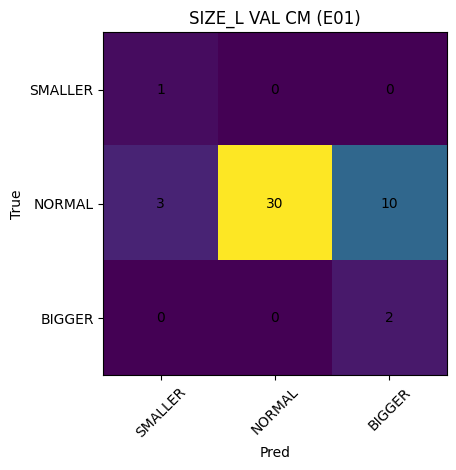

OK Saved best: G:\Tasfique's\best_SIZE_L_gtmask.pt | best: 0.5025440313111545


SIZE_L train E02: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E02] tr_loss=1.4900 va_loss=1.3258 val_f1m=0.3675 | perF1=['0.286', '0.635', '0.182'] | 254.2s


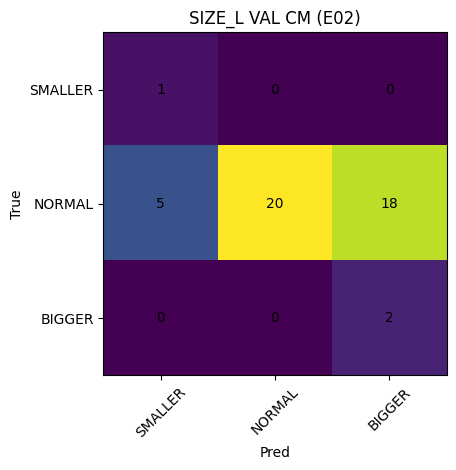

EarlyStop: no improve 1/7 | best=0.5025440313111545


SIZE_L train E03: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E03] tr_loss=1.3471 va_loss=0.2595 val_f1m=0.6699 | perF1=['0.500', '0.938', '0.571'] | 254.7s


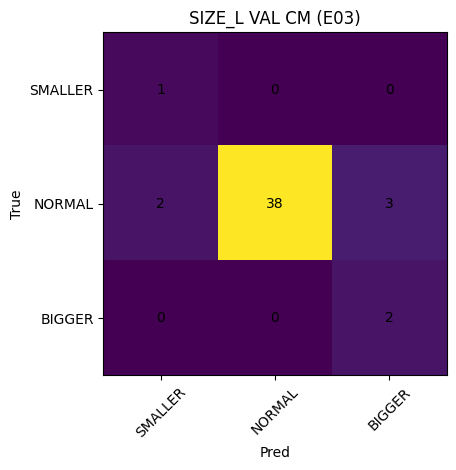

OK Saved best: G:\Tasfique's\best_SIZE_L_gtmask.pt | best: 0.6699000587889476


SIZE_L train E04: 100%|██████████| 694/694 [04:10<00:00,  2.77it/s]
                                                                 

[SIZE_L][E04] tr_loss=1.0912 va_loss=1.1029 val_f1m=0.4689 | perF1=['0.400', '0.771', '0.235'] | 253.8s


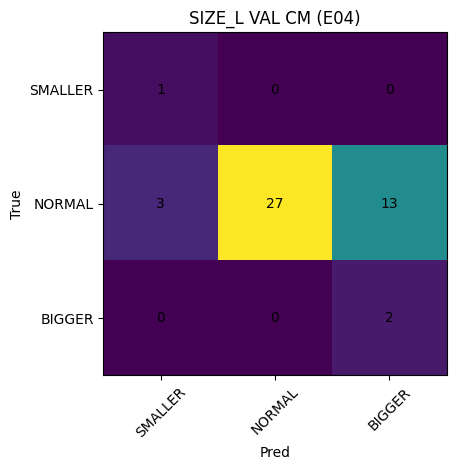

EarlyStop: no improve 1/7 | best=0.6699000587889476


SIZE_L train E05: 100%|██████████| 694/694 [04:10<00:00,  2.77it/s]
                                                                 

[SIZE_L][E05] tr_loss=0.9514 va_loss=0.5201 val_f1m=0.6047 | perF1=['0.250', '0.897', '0.667'] | 253.4s


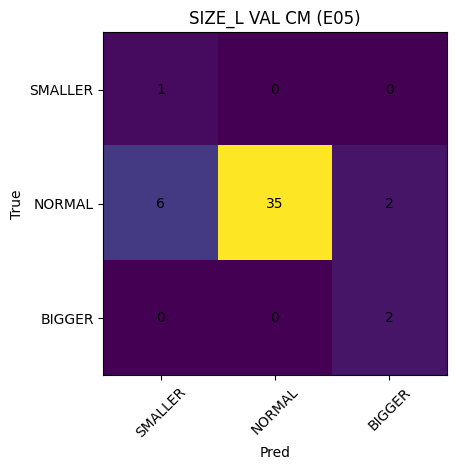

EarlyStop: no improve 2/7 | best=0.6699000587889476


SIZE_L train E06: 100%|██████████| 694/694 [04:10<00:00,  2.77it/s]
                                                                 

[SIZE_L][E06] tr_loss=0.9229 va_loss=0.8608 val_f1m=0.4357 | perF1=['0.250', '0.771', '0.286'] | 253.4s


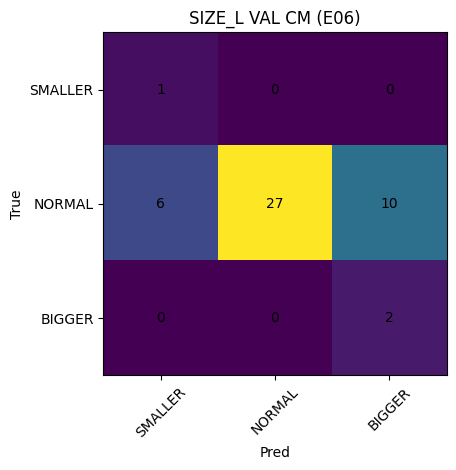

EarlyStop: no improve 3/7 | best=0.6699000587889476


SIZE_L train E07: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E07] tr_loss=0.8530 va_loss=0.5352 val_f1m=0.4850 | perF1=['0.250', '0.872', '0.333'] | 254.0s


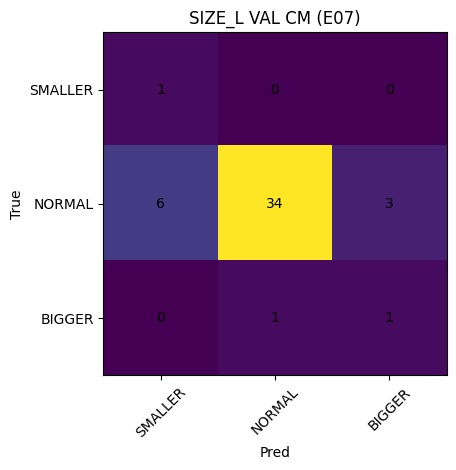

EarlyStop: no improve 4/7 | best=0.6699000587889476


SIZE_L train E08: 100%|██████████| 694/694 [04:12<00:00,  2.75it/s]
                                                                 

[SIZE_L][E08] tr_loss=0.8103 va_loss=1.0956 val_f1m=0.4081 | perF1=['0.286', '0.716', '0.222'] | 255.2s


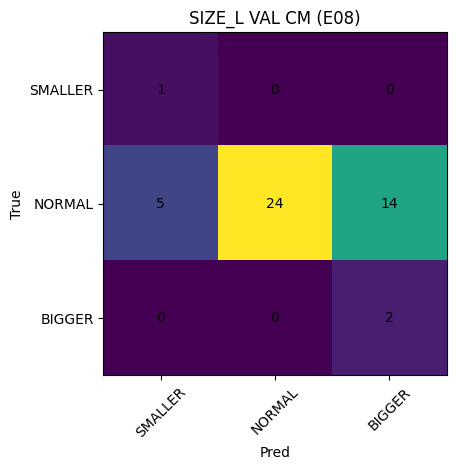

EarlyStop: no improve 5/7 | best=0.6699000587889476


SIZE_L train E09: 100%|██████████| 694/694 [04:12<00:00,  2.75it/s]
                                                                 

[SIZE_L][E09] tr_loss=0.7803 va_loss=0.3075 val_f1m=0.6730 | perF1=['0.667', '0.952', '0.400'] | 255.3s


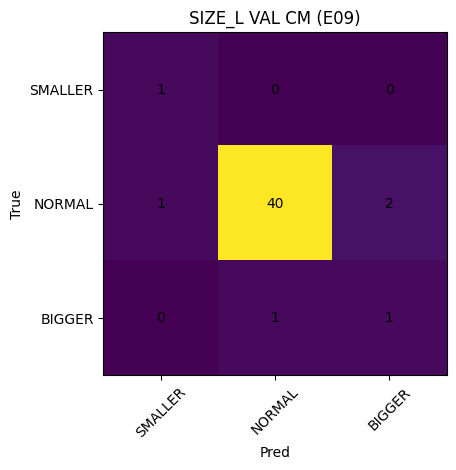

OK Saved best: G:\Tasfique's\best_SIZE_L_gtmask.pt | best: 0.673015873015873


SIZE_L train E10: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E10] tr_loss=0.7284 va_loss=1.0283 val_f1m=0.3376 | perF1=['0.133', '0.613', '0.267'] | 254.3s


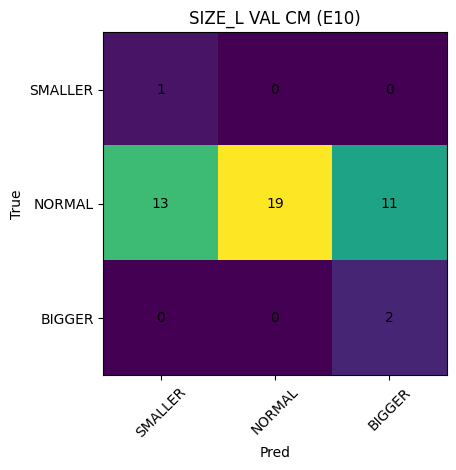

EarlyStop: no improve 1/7 | best=0.673015873015873


SIZE_L train E11: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E11] tr_loss=0.7287 va_loss=0.5600 val_f1m=0.5682 | perF1=['0.250', '0.883', '0.571'] | 254.5s


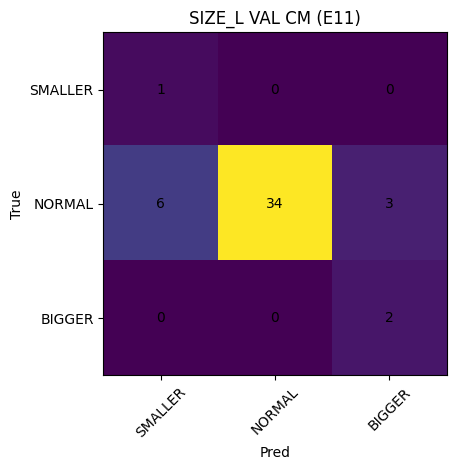

EarlyStop: no improve 2/7 | best=0.673015873015873


SIZE_L train E12: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E12] tr_loss=0.7276 va_loss=0.5681 val_f1m=0.5769 | perF1=['0.333', '0.897', '0.500'] | 254.6s


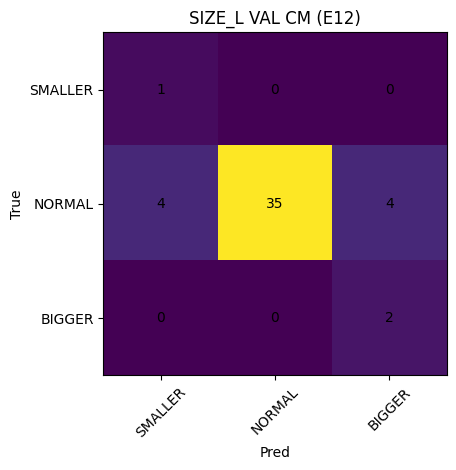

EarlyStop: no improve 3/7 | best=0.673015873015873


SIZE_L train E13: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E13] tr_loss=0.7168 va_loss=0.8094 val_f1m=0.4534 | perF1=['0.286', '0.789', '0.286'] | 254.1s


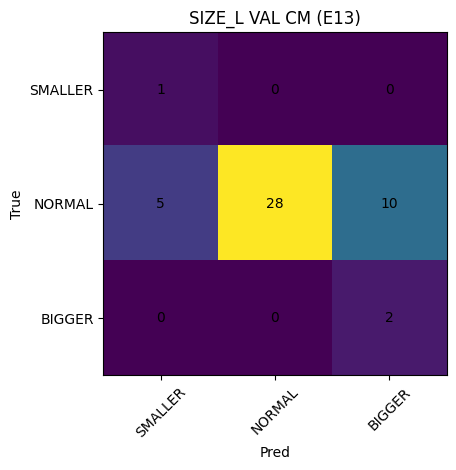

EarlyStop: no improve 4/7 | best=0.673015873015873


SIZE_L train E14: 100%|██████████| 694/694 [04:12<00:00,  2.75it/s]
                                                                 

[SIZE_L][E14] tr_loss=0.7055 va_loss=0.4288 val_f1m=0.6321 | perF1=['0.400', '0.925', '0.571'] | 255.0s


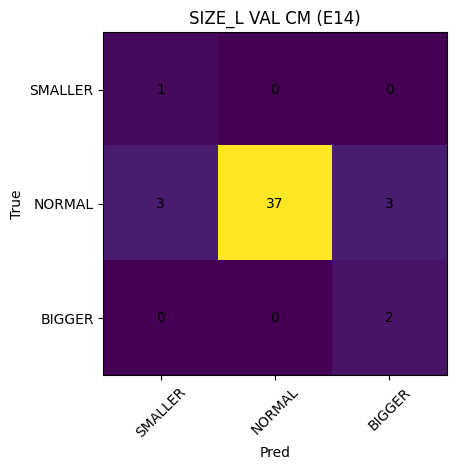

EarlyStop: no improve 5/7 | best=0.673015873015873


SIZE_L train E15: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E15] tr_loss=0.7027 va_loss=0.6109 val_f1m=0.5289 | perF1=['0.400', '0.853', '0.333'] | 254.3s


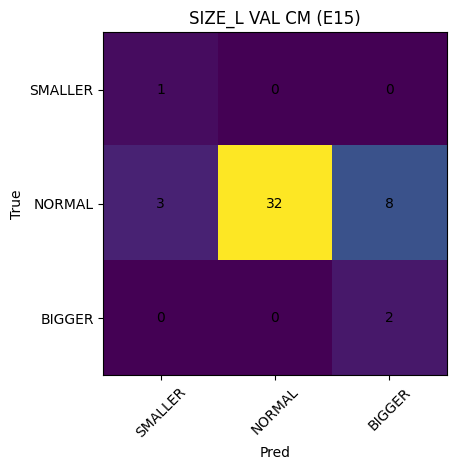

EarlyStop: no improve 6/7 | best=0.673015873015873


SIZE_L train E16: 100%|██████████| 694/694 [04:11<00:00,  2.76it/s]
                                                                 

[SIZE_L][E16] tr_loss=0.6997 va_loss=0.6356 val_f1m=0.5563 | perF1=['0.286', '0.883', '0.500'] | 254.7s


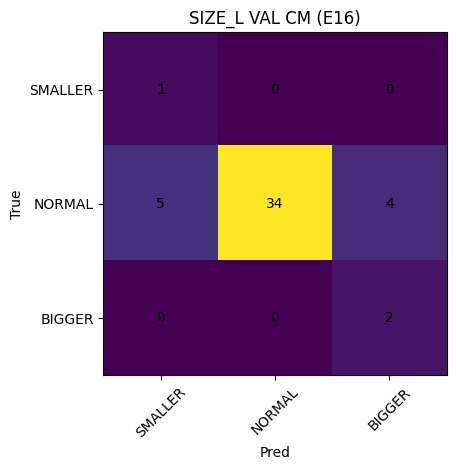

C:\Users\muhta\AppData\Local\Temp\ipykernel_24212\3357370083.py:554: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(best_path, map_location=DEVICE)


EarlyStop: no improve 7/7 | best=0.673015873015873
STOP Early stop triggered.

OK Reloaded best: G:\Tasfique's\best_SIZE_L_gtmask.pt | epoch: 9 | best: 0.673015873015873


SIZE_L TEST (full): 100%|██████████| 60/60 [00:03<00:00, 17.29it/s]


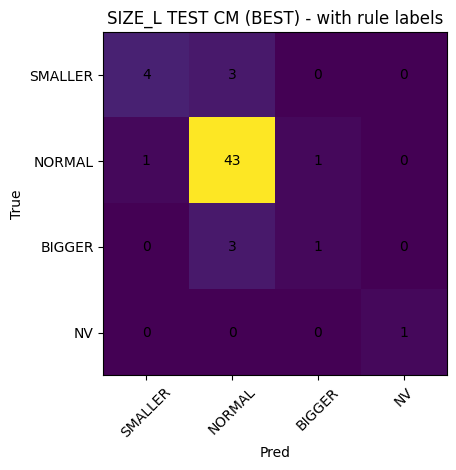

[SIZE_L] TEST macro F1=0.7287 | perF1=['0.667', '0.915', '0.333', '1.000']


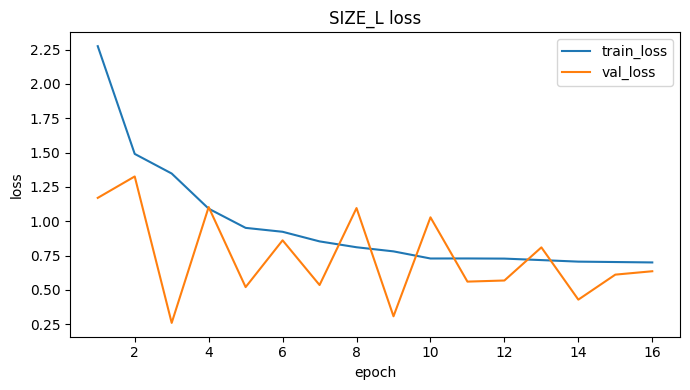

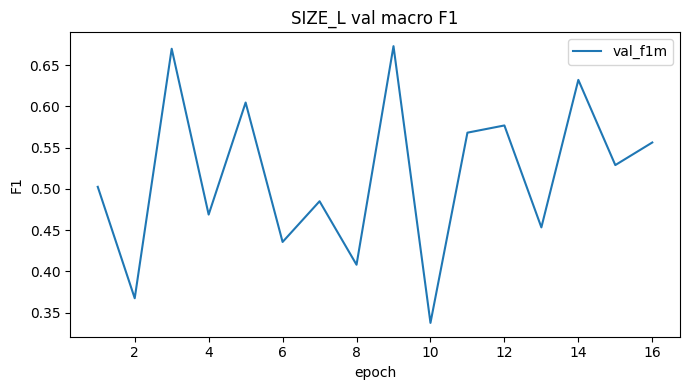


TRAIN HEAD: SIZE_R | classes: ['SMALLER', 'NORMAL', 'BIGGER'] | view weights: [0.75, 0.125, 0.125]
Batch size: 1 | AMP: False | Accum: 1 | Backbone: convnext_tiny
Valid counts | train: 415 | val: 45 | test: 47
Feature dim: 11 | oversampled train ids: 700


Raw class counts: [48, 320, 47]
Class weights: [1.2511, 0.4846, 1.2643]


SIZE_R train E01: 100%|██████████| 700/700 [04:18<00:00,  2.70it/s]


[SIZE_R][E01] tr_loss=2.0754 va_loss=0.9463 val_f1m=0.6171 | perF1=['0.615', '0.836', '0.400'] | 261.8s


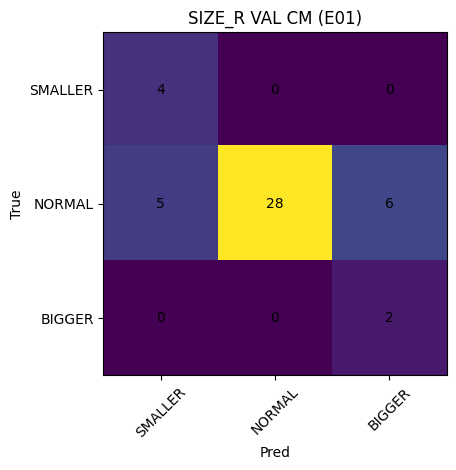

OK Saved best: G:\Tasfique's\best_SIZE_R_gtmask.pt | best: 0.6170685036356679


SIZE_R train E02: 100%|██████████| 700/700 [04:18<00:00,  2.71it/s]
                                                                 

[SIZE_R][E02] tr_loss=1.7163 va_loss=0.6887 val_f1m=0.5146 | perF1=['0.250', '0.849', '0.444'] | 261.4s


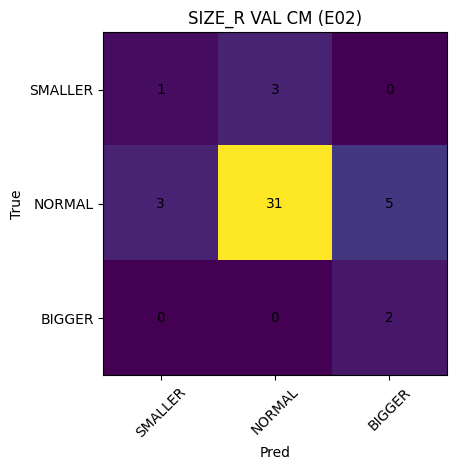

EarlyStop: no improve 1/7 | best=0.6170685036356679


SIZE_R train E03: 100%|██████████| 700/700 [04:18<00:00,  2.70it/s]


[SIZE_R][E03] tr_loss=1.4307 va_loss=0.4050 val_f1m=0.3810 | perF1=['0.000', '0.857', '0.286'] | 261.8s


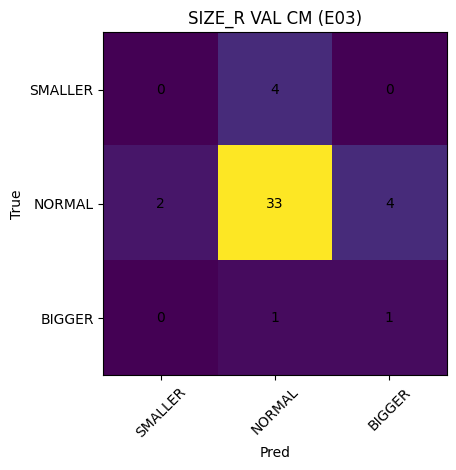

EarlyStop: no improve 2/7 | best=0.6170685036356679


SIZE_R train E04: 100%|██████████| 700/700 [04:19<00:00,  2.70it/s]
                                                                 

[SIZE_R][E04] tr_loss=1.1786 va_loss=0.9990 val_f1m=0.5779 | perF1=['0.667', '0.781', '0.286'] | 262.1s


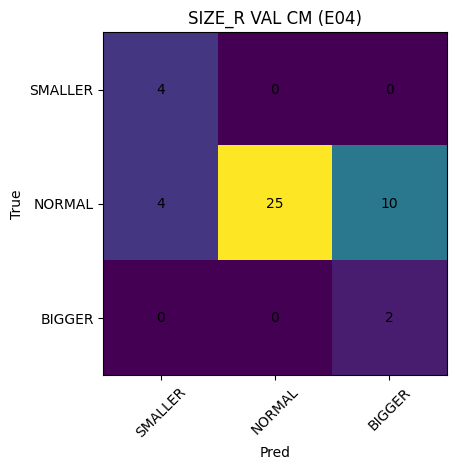

EarlyStop: no improve 3/7 | best=0.6170685036356679


SIZE_R train E05: 100%|██████████| 700/700 [04:18<00:00,  2.71it/s]


[SIZE_R][E05] tr_loss=1.0880 va_loss=1.1390 val_f1m=0.5561 | perF1=['0.800', '0.678', '0.190'] | 261.2s


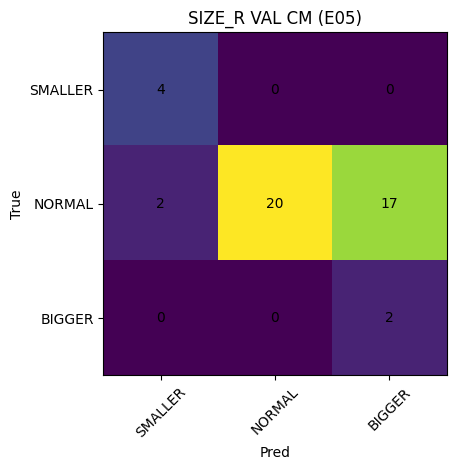

EarlyStop: no improve 4/7 | best=0.6170685036356679


SIZE_R train E06: 100%|██████████| 700/700 [04:10<00:00,  2.79it/s]
                                                                 

[SIZE_R][E06] tr_loss=0.9917 va_loss=0.5947 val_f1m=0.6190 | perF1=['0.500', '0.857', '0.500'] | 253.8s


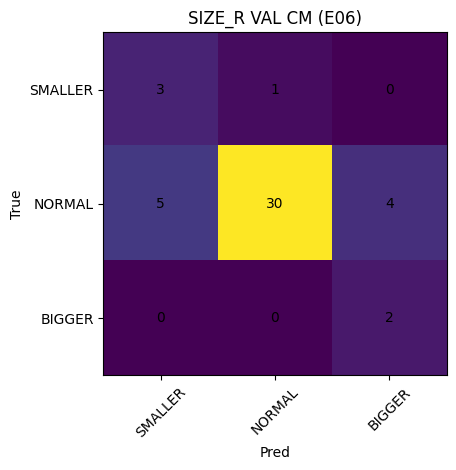

OK Saved best: G:\Tasfique's\best_SIZE_R_gtmask.pt | best: 0.6190476190476191


SIZE_R train E07: 100%|██████████| 700/700 [04:11<00:00,  2.79it/s]


[SIZE_R][E07] tr_loss=0.9437 va_loss=0.4747 val_f1m=0.7556 | perF1=['0.667', '0.933', '0.667'] | 254.0s


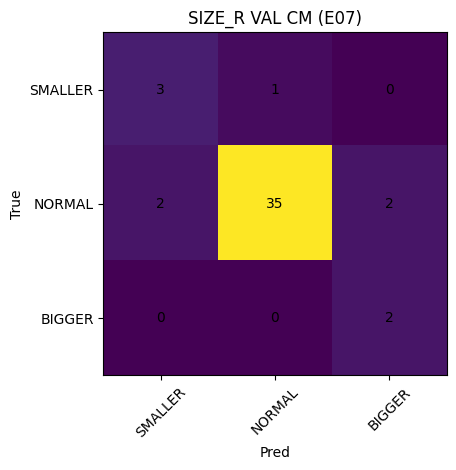

OK Saved best: G:\Tasfique's\best_SIZE_R_gtmask.pt | best: 0.7555555555555555


SIZE_R train E08: 100%|██████████| 700/700 [04:10<00:00,  2.79it/s]


[SIZE_R][E08] tr_loss=0.8297 va_loss=0.5435 val_f1m=0.7385 | perF1=['0.727', '0.917', '0.571'] | 253.8s


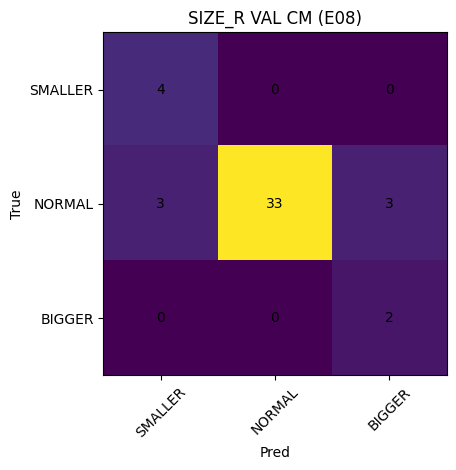

EarlyStop: no improve 1/7 | best=0.7555555555555555


SIZE_R train E09: 100%|██████████| 700/700 [04:10<00:00,  2.79it/s]


[SIZE_R][E09] tr_loss=0.7581 va_loss=0.5660 val_f1m=0.7190 | perF1=['0.667', '0.919', '0.571'] | 253.5s


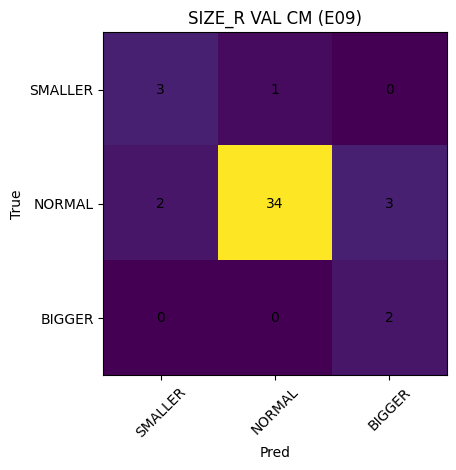

EarlyStop: no improve 2/7 | best=0.7555555555555555


SIZE_R train E10: 100%|██████████| 700/700 [04:10<00:00,  2.79it/s]


[SIZE_R][E10] tr_loss=0.7659 va_loss=0.5911 val_f1m=0.6569 | perF1=['0.667', '0.904', '0.400'] | 253.6s


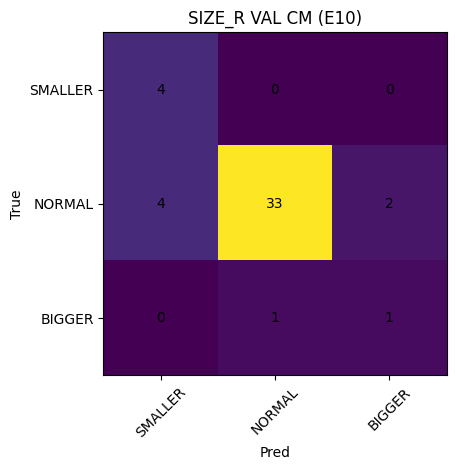

EarlyStop: no improve 3/7 | best=0.7555555555555555


SIZE_R train E11: 100%|██████████| 700/700 [04:10<00:00,  2.79it/s]


[SIZE_R][E11] tr_loss=0.7578 va_loss=0.7100 val_f1m=0.6171 | perF1=['0.615', '0.836', '0.400'] | 253.5s


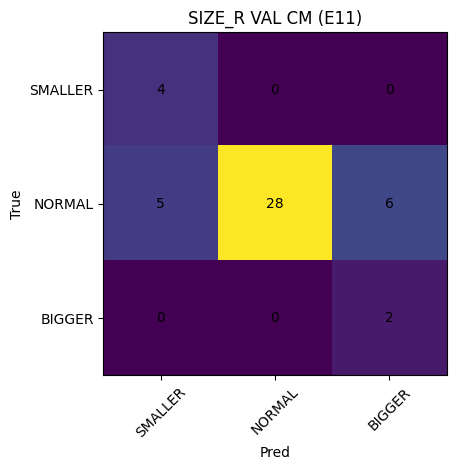

EarlyStop: no improve 4/7 | best=0.7555555555555555


SIZE_R train E12: 100%|██████████| 700/700 [04:10<00:00,  2.80it/s]


[SIZE_R][E12] tr_loss=0.7156 va_loss=0.5460 val_f1m=0.6148 | perF1=['0.667', '0.892', '0.286'] | 253.3s


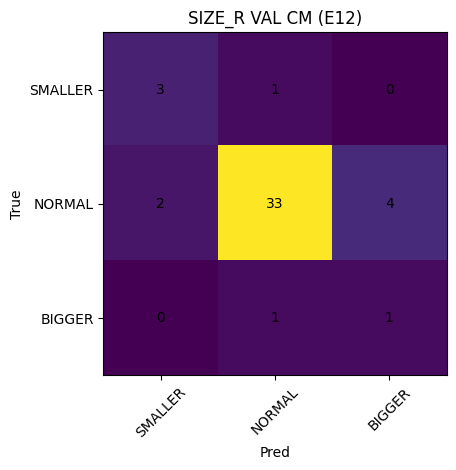

EarlyStop: no improve 5/7 | best=0.7555555555555555


SIZE_R train E13: 100%|██████████| 700/700 [04:10<00:00,  2.80it/s]
                                                                 

[SIZE_R][E13] tr_loss=0.7231 va_loss=0.5404 val_f1m=0.6821 | perF1=['0.727', '0.919', '0.400'] | 253.2s


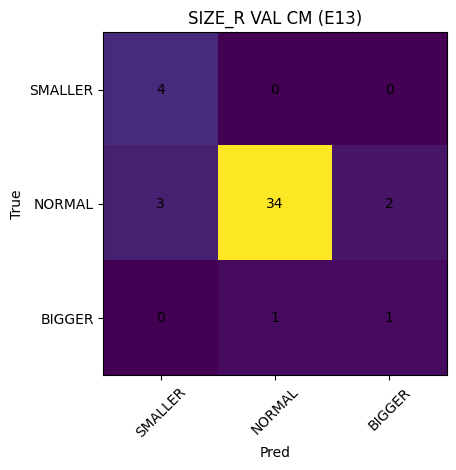

EarlyStop: no improve 6/7 | best=0.7555555555555555


SIZE_R train E14: 100%|██████████| 700/700 [04:10<00:00,  2.79it/s]


[SIZE_R][E14] tr_loss=0.7291 va_loss=0.5144 val_f1m=0.5552 | perF1=['0.286', '0.880', '0.500'] | 253.4s


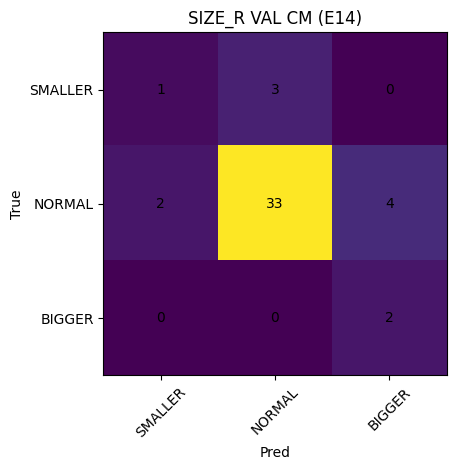

C:\Users\muhta\AppData\Local\Temp\ipykernel_24212\3357370083.py:554: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(best_path, map_location=DEVICE)


EarlyStop: no improve 7/7 | best=0.7555555555555555
STOP Early stop triggered.

OK Reloaded best: G:\Tasfique's\best_SIZE_R_gtmask.pt | epoch: 7 | best: 0.7555555555555555


SIZE_R TEST (full): 100%|██████████| 60/60 [00:03<00:00, 16.37it/s]


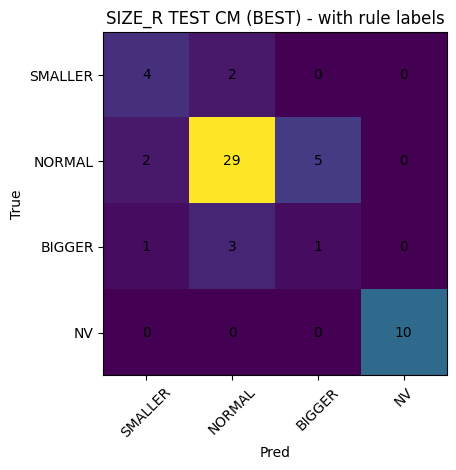

[SIZE_R] TEST macro F1=0.6564 | perF1=['0.615', '0.829', '0.182', '1.000']


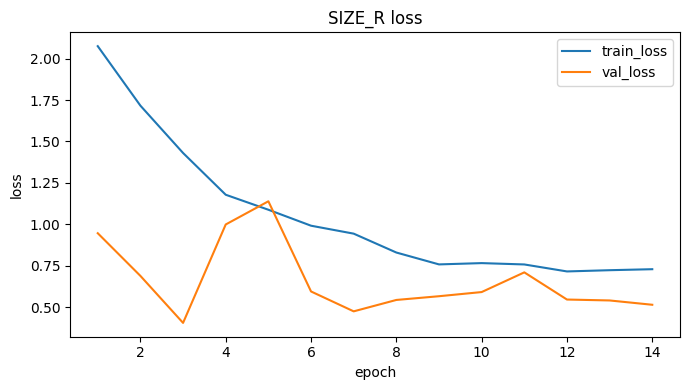

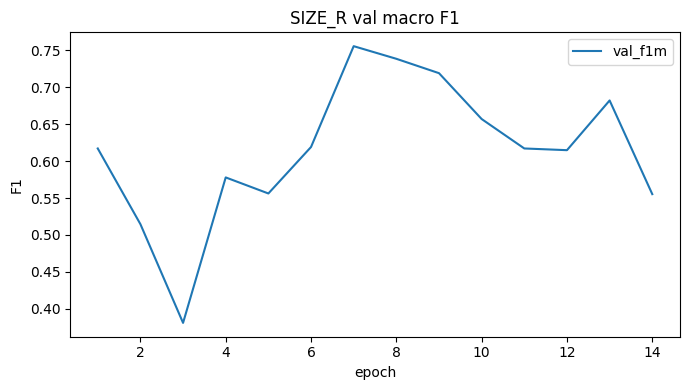


TRAIN HEAD: UP_L | classes: ['NORMAL', 'REDUCED'] | view weights: [0.6000000238418579, 0.25, 0.15000000596046448]
Batch size: 1 | AMP: False | Accum: 1 | Backbone: convnext_tiny
Valid counts | train: 429 | val: 51 | test: 59
Feature dim: 11 | oversampled train ids: 550
Raw class counts: [308, 121]
Class weights: [0.7706, 1.2294]


UP_L train E01: 100%|██████████| 550/550 [03:16<00:00,  2.79it/s]
                                                               

[UP_L][E01] tr_loss=2.0300 va_loss=0.6280 val_f1m=0.6556 | perF1=['0.831', '0.480'] | 200.1s


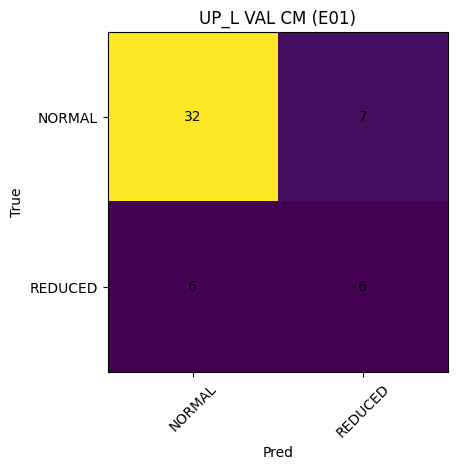

In [ ]:
# CELL 24 - TRAIN + EVAL FOR SIZE + UPTAKE HEADS (ConvNeXt-Base, GT masks) - STRONGER FEATURES + SAFER EARLY STOP

import math
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from contextlib import nullcontext

if "DEVICE" not in globals():
    raise RuntimeError("DEVICE not set. Run the GPU check cell first.")
if str(DEVICE).lower() == "cpu":
    raise RuntimeError("GPU required. DEVICE resolved to CPU.")
print("DEVICE (enforced):", DEVICE)

torch.manual_seed(SEED)
np.random.seed(SEED)

# =========================
# MEMORY-SAFE OVERRIDES
# =========================
BATCH_SIZE_OVERRIDE = 1   # set None to use global BATCH_SIZE
GRAD_ACCUM_STEPS = 1      # set >1 to simulate larger batch
USE_AMP = True            # mixed precision
BACKBONE_NAME = "convnext_tiny"  # "convnext_base" if you have enough VRAM

BATCH_SIZE_LOCAL = int(BATCH_SIZE_OVERRIDE) if BATCH_SIZE_OVERRIDE is not None else int(BATCH_SIZE)
ACCUM = max(1, int(GRAD_ACCUM_STEPS))

torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
if hasattr(torch, "set_float32_matmul_precision"):
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# -------------------------
# Future-proof AMP helpers
# -------------------------
AMP_ENABLED = bool(USE_AMP and torch.cuda.is_available())

class _DummyScaler:
    def scale(self, loss):
        return loss
    def step(self, opt):
        opt.step()
    def update(self):
        pass

def _make_scaler():
    if AMP_ENABLED and hasattr(torch.cuda, "amp") and hasattr(torch.cuda.amp, "GradScaler"):
        try:
            return torch.cuda.amp.GradScaler(enabled=True)
        except TypeError:
            try:
                return torch.cuda.amp.GradScaler()
            except Exception:
                pass
    return _DummyScaler()

def _autocast_ctx():
    if not AMP_ENABLED:
        return nullcontext()
    # Prefer torch.autocast if available (newer API)
    if hasattr(torch, "autocast"):
        try:
            return torch.autocast(device_type="cuda", dtype=torch.float16)
        except TypeError:
            try:
                return torch.autocast("cuda")
            except Exception:
                pass
    # Fallback to torch.cuda.amp.autocast
    if hasattr(torch.cuda, "amp") and hasattr(torch.cuda.amp, "autocast"):
        try:
            return torch.cuda.amp.autocast()
        except TypeError:
            try:
                return torch.cuda.amp.autocast(enabled=True)
            except Exception:
                pass
    return nullcontext()

scaler = _make_scaler()

SIZE3 = ["SMALLER", "NORMAL", "BIGGER"]
SIZE4 = ["SMALLER", "NORMAL", "BIGGER", "NV"]
UP2   = ["NORMAL", "REDUCED"]
UP3   = ["NORMAL", "REDUCED", "NOT APPLICABLE"]


def get_size_label(row, side):
    return norm_str(row[COL_SZ_L if side == "L" else COL_SZ_R])


def get_uptake_label(row, side):
    return norm_str(row[COL_UP_L if side == "L" else COL_UP_R])


def is_po(lab):
    return lab == "PO"


def _pick_label_row(pid):
    rows = patient_views(pid)
    ri = rows[0] if rows[0] is not None else (rows[1] if rows[1] is not None else rows[2])
    return df.iloc[int(ri)]


def _label_for_pid(head_name, pid):
    row = _pick_label_row(pid)
    Lp, Rp = patient_presence(pid)

    if head_name == "SIZE_L":
        lab = get_size_label(row, "L")
        if (not Lp) or lab in ("NV", "") or is_po(lab):
            return None
        return SIZE3.index(lab)
    if head_name == "SIZE_R":
        lab = get_size_label(row, "R")
        if (not Rp) or lab in ("NV", "") or is_po(lab):
            return None
        return SIZE3.index(lab)
    if head_name == "UP_L":
        lab = get_uptake_label(row, "L")
        if (not Lp) or lab in ("NOT APPLICABLE", ""):
            return None
        return UP2.index(lab)
    if head_name == "UP_R":
        lab = get_uptake_label(row, "R")
        if (not Rp) or lab in ("NOT APPLICABLE", ""):
            return None
        return UP2.index(lab)
    return None


def _count_valid(pids, head_name):
    n = 0
    for pid in pids:
        if _label_for_pid(head_name, pid) is not None:
            n += 1
    return n


def _as_np_w(w_view):
    if isinstance(w_view, np.ndarray):
        return w_view.astype(np.float32)
    if torch.is_tensor(w_view):
        return w_view.detach().cpu().numpy().astype(np.float32)
    return np.asarray(w_view, dtype=np.float32)


def _safe_mean(I, mask):
    m = mask > 0
    if not bool(m.any()):
        return 0.0
    return float(I[m].mean())


def _fuse(values, w, valid):
    ww = w * valid
    den = float(ww.sum())
    if den <= 0:
        return 0.0
    return float((values * ww).sum() / den)


def _log_ratio(a, b, eps=1e-6):
    return float(math.log((eps + a) / (eps + b)))


def _build_feat(head_name, w_view, axL, axR, areaL, areaR, meanL, meanR, presL, presR):
    w = _as_np_w(w_view)

    axL_f = _fuse(axL, w, presL)
    axR_f = _fuse(axR, w, presR)
    areaL_f = _fuse(areaL, w, presL)
    areaR_f = _fuse(areaR, w, presR)
    meanL_f = _fuse(meanL, w, presL)
    meanR_f = _fuse(meanR, w, presR)

    nL = float(presL.sum()) / 3.0
    nR = float(presR.sum()) / 3.0

    if head_name in ("SIZE_L", "SIZE_R"):
        feat = np.array(
            [
                axL_f, axR_f, areaL_f, areaR_f, meanL_f, meanR_f,
                _log_ratio(axL_f, axR_f),
                _log_ratio(areaL_f, areaR_f),
                _log_ratio(meanL_f, meanR_f),
                nL, nR,
            ],
            dtype=np.float32,
        )
        return feat

    if head_name == "UP_L":
        t_mean, o_mean = meanL_f, meanR_f
        t_area, o_area = areaL_f, areaR_f
        t_ax, o_ax = axL_f, axR_f
        t_n, o_n = nL, nR
    else:
        t_mean, o_mean = meanR_f, meanL_f
        t_area, o_area = areaR_f, areaL_f
        t_ax, o_ax = axR_f, axL_f
        t_n, o_n = nR, nL

    feat = np.array(
        [
            t_mean, o_mean, _log_ratio(t_mean, o_mean),
            t_area, o_area, _log_ratio(t_area, o_area),
            t_ax, o_ax, _log_ratio(t_ax, o_ax),
            t_n, o_n,
        ],
        dtype=np.float32,
    )
    return feat


class PatientHeadDataset(Dataset):
    def __init__(self, pids, head_name, w_view):
        self.pids = list(pids)
        self.head = head_name
        self.w_view = w_view

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[int(idx)]
        rows = patient_views(pid)

        X = np.zeros((3, 4, IMG_SIZE, IMG_SIZE), dtype=np.float32)

        axL = np.zeros((3,), dtype=np.float32)
        axR = np.zeros((3,), dtype=np.float32)
        areaL = np.zeros((3,), dtype=np.float32)
        areaR = np.zeros((3,), dtype=np.float32)
        meanL = np.zeros((3,), dtype=np.float32)
        meanR = np.zeros((3,), dtype=np.float32)
        presL = np.zeros((3,), dtype=np.float32)
        presR = np.zeros((3,), dtype=np.float32)

        for vi, ri in enumerate(rows):
            if ri is None:
                continue
            I, mL, mR = _get_row_view_tensor(ri)

            if self.head.startswith("SIZE"):
                X[vi] = build_input4(I, mL, mR, mode="SIZE")
            elif self.head == "UP_L":
                X[vi] = build_input4(I, mL, mR, mode="UP_L")
            elif self.head == "UP_R":
                X[vi] = build_input4(I, mL, mR, mode="UP_R")
            else:
                X[vi] = build_input4(I, mL, mR, mode="GEN")

            axL[vi] = major_axis_len(mL)
            axR[vi] = major_axis_len(mR)
            areaL[vi] = float(mL.sum())
            areaR[vi] = float(mR.sum())
            meanL[vi] = _safe_mean(I, mL)
            meanR[vi] = _safe_mean(I, mR)
            presL[vi] = 1.0 if areaL[vi] > 0 else 0.0
            presR[vi] = 1.0 if areaR[vi] > 0 else 0.0

        Lp, Rp = patient_presence(pid)
        row = _pick_label_row(pid)

        if self.head == "SIZE_L":
            lab = get_size_label(row, "L")
            if (not Lp) or lab in ("NV", "") or is_po(lab):
                y = -1; valid = 0
            else:
                y = SIZE3.index(lab); valid = 1
        elif self.head == "SIZE_R":
            lab = get_size_label(row, "R")
            if (not Rp) or lab in ("NV", "") or is_po(lab):
                y = -1; valid = 0
            else:
                y = SIZE3.index(lab); valid = 1
        elif self.head == "UP_L":
            lab = get_uptake_label(row, "L")
            if (not Lp) or lab in ("NOT APPLICABLE", ""):
                y = -1; valid = 0
            else:
                y = UP2.index(lab); valid = 1
        elif self.head == "UP_R":
            lab = get_uptake_label(row, "R")
            if (not Rp) or lab in ("NOT APPLICABLE", ""):
                y = -1; valid = 0
            else:
                y = UP2.index(lab); valid = 1
        else:
            y = -1; valid = 0

        feat = _build_feat(self.head, self.w_view, axL, axR, areaL, areaR, meanL, meanR, presL, presR)

        return {
            "pid": pid,
            "x": torch.from_numpy(X),
            "feat": torch.from_numpy(feat),
            "y": torch.tensor(int(y), dtype=torch.long),
            "valid": torch.tensor(int(valid), dtype=torch.long),
            "Lp": torch.tensor(int(Lp), dtype=torch.long),
            "Rp": torch.tensor(int(Rp), dtype=torch.long),
        }


def make_oversampled_train_pids(head_name):
    out = []
    for pid in train_p:
        row = _pick_label_row(pid)
        Lp, Rp = patient_presence(pid)

        if head_name == "SIZE_L":
            lab = get_size_label(row, "L")
            if (not Lp) or lab in ("NV", "PO", ""):
                continue
            mult = OVERSAMPLE["SIZE_L"].get(lab, 1)
        elif head_name == "SIZE_R":
            lab = get_size_label(row, "R")
            if (not Rp) or lab in ("NV", "PO", ""):
                continue
            mult = OVERSAMPLE["SIZE_R"].get(lab, 1)
        elif head_name == "UP_L":
            lab = get_uptake_label(row, "L")
            if (not Lp) or lab in ("NOT APPLICABLE", ""):
                continue
            mult = OVERSAMPLE["UP_L"].get(lab, 1)
        elif head_name == "UP_R":
            lab = get_uptake_label(row, "R")
            if (not Rp) or lab in ("NOT APPLICABLE", ""):
                continue
            mult = OVERSAMPLE["UP_R"].get(lab, 1)
        else:
            continue

        for _ in range(int(mult)):
            out.append(pid)
    return out


def _class_weights_from_train(head_name, n_classes):
    counts = np.zeros((n_classes,), dtype=np.float64)
    for pid in train_p:
        y = _label_for_pid(head_name, pid)
        if y is None:
            continue
        if 0 <= int(y) < n_classes:
            counts[int(y)] += 1.0

    if counts.sum() <= 0:
        return None, counts

    inv = 1.0 / np.sqrt(np.maximum(counts, 1.0))
    weights = inv * (float(n_classes) / float(inv.sum()))
    w_t = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    return w_t, counts


class ConvNeXtHead(nn.Module):
    def __init__(self, n_classes, feat_dim):
        super().__init__()
        self.feat_dim = int(feat_dim)
        self.backbone = timm.create_model(
            BACKBONE_NAME,
            pretrained=True,
            in_chans=4,
            num_classes=0,
            global_pool="avg",
        )
        self.fc = nn.Sequential(
            nn.Linear(self.backbone.num_features + self.feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, n_classes),
        )

    def forward(self, x3v, feat, w):
        logits = 0
        for vi in range(3):
            f = self.backbone(x3v[:, vi])
            f = torch.cat([f, feat], dim=1)
            lv = self.fc(f)
            logits = logits + float(w[vi]) * lv
        return logits


def train_head(head_name, n_classes, class_names, w_view, max_epochs=30):
    print("\n" + "=" * 110)
    print("TRAIN HEAD:", head_name, "| classes:", class_names, "| view weights:", w_view.tolist())
    print("Batch size:", BATCH_SIZE_LOCAL, "| AMP:", AMP_ENABLED, "| Accum:", ACCUM, "| Backbone:", BACKBONE_NAME)
    print("=" * 110)

    print("Valid counts | train:", _count_valid(train_p, head_name), "| val:", _count_valid(val_p, head_name), "| test:", _count_valid(test_p, head_name))

    torch.cuda.empty_cache()

    tr_ids = make_oversampled_train_pids(head_name)
    tr_ds = PatientHeadDataset(tr_ids, head_name, w_view=w_view)
    va_ds = PatientHeadDataset(val_p, head_name, w_view=w_view)
    te_ds = PatientHeadDataset(test_p, head_name, w_view=w_view)

    feat_dim = int(tr_ds[0]["feat"].numel()) if len(tr_ds) else int(va_ds[0]["feat"].numel())
    print("Feature dim:", feat_dim, "| oversampled train ids:", len(tr_ids))

    tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE_LOCAL, shuffle=True, num_workers=NUM_WORKERS)
    va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE_LOCAL, shuffle=False, num_workers=NUM_WORKERS)
    te_dl = DataLoader(te_ds, batch_size=BATCH_SIZE_LOCAL, shuffle=False, num_workers=NUM_WORKERS)

    model = ConvNeXtHead(n_classes=n_classes, feat_dim=feat_dim).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    class_w, raw_counts = _class_weights_from_train(head_name, n_classes)
    if class_w is not None:
        print("Raw class counts:", raw_counts.astype(int).tolist())
        print("Class weights:", [round(float(x), 4) for x in class_w.detach().cpu().tolist()])
    loss_fn = nn.CrossEntropyLoss(weight=class_w)

    best_path = BASE_DIR / f"best_{head_name}_gtmask.pt"
    torch.save({"model": model.state_dict(), "epoch": 0, "best": -1.0}, best_path)
    best = -1.0
    bad = 0

    hist_tr = []
    hist_va = []
    hist_f1 = []

    for ep in range(1, max_epochs + 1):
        t0 = time.time()
        model.train()
        tr_loss = 0.0
        tr_n = 0

        opt.zero_grad(set_to_none=True)
        accum_count = 0

        for batch in tqdm(tr_dl, desc=f"{head_name} train E{ep:02d}"):
            x = batch["x"].to(DEVICE, non_blocking=True)
            feat = batch["feat"].to(DEVICE, non_blocking=True)
            y = batch["y"].to(DEVICE, non_blocking=True)
            valid = batch["valid"].to(DEVICE, non_blocking=True)

            m = valid == 1
            if int(m.sum()) == 0:
                continue
            x = x[m]
            feat = feat[m]
            y = y[m]

            with _autocast_ctx():
                logits = model(x, feat, w_view)
                loss_raw = loss_fn(logits, y)
                loss = loss_raw / ACCUM

            scaled = scaler.scale(loss)
            scaled.backward()

            accum_count += 1
            if accum_count % ACCUM == 0:
                scaler.step(opt)
                scaler.update()
                opt.zero_grad(set_to_none=True)

            tr_loss += float(loss_raw.item()) * y.size(0)
            tr_n += y.size(0)

        if accum_count > 0 and (accum_count % ACCUM) != 0:
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)

        tr_loss = tr_loss / max(tr_n, 1)

        model.eval()
        va_loss = 0.0
        va_n = 0
        y_true = []
        y_pred = []
        with torch.no_grad():
            for batch in tqdm(va_dl, desc=f"{head_name} val   E{ep:02d}", leave=False):
                x = batch["x"].to(DEVICE, non_blocking=True)
                feat = batch["feat"].to(DEVICE, non_blocking=True)
                y = batch["y"].to(DEVICE, non_blocking=True)
                valid = batch["valid"].to(DEVICE, non_blocking=True)

                m = valid == 1
                if int(m.sum()) == 0:
                    continue
                x = x[m]
                feat = feat[m]
                y = y[m]

                with _autocast_ctx():
                    logits = model(x, feat, w_view)
                    loss = loss_fn(logits, y)

                va_loss += float(loss.item()) * y.size(0)
                va_n += y.size(0)

                yp = torch.argmax(logits, dim=1).detach().cpu().numpy().tolist()
                yt = y.detach().cpu().numpy().tolist()
                y_true.extend([int(t) for t in yt])
                y_pred.extend([int(p) for p in yp])

        hist_tr.append(tr_loss)

        if va_n == 0:
            bad += 1
            hist_va.append(float("nan"))
            hist_f1.append(-1.0)
            print(f"[{head_name}][E{ep:02d}] tr_loss={tr_loss:.4f} | VAL has 0 eligible samples | bad {bad}/{PATIENCE} | {time.time()-t0:.1f}s")
            if EARLY_STOP_ON and bad >= int(PATIENCE):
                print("STOP Early stop (no val samples) triggered.")
                break
            continue

        va_loss = va_loss / max(va_n, 1)
        cm = confusion_matrix_np(y_true, y_pred, n_classes)
        f1s, f1m = f1_macro_from_cm(cm)

        hist_va.append(va_loss)
        hist_f1.append(f1m)

        print(
            f"[{head_name}][E{ep:02d}] tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} val_f1m={f1m:.4f}"
            f" | perF1={['%.3f' % x for x in f1s]} | {time.time()-t0:.1f}s"
        )
        plot_cm(cm, f"{head_name} VAL CM (E{ep:02d})", class_names)

        score = f1m
        improved = score > best + MIN_DELTA
        if improved:
            best = score
            bad = 0
            torch.save({"model": model.state_dict(), "epoch": ep, "best": best}, best_path)
            print("OK Saved best:", best_path, "| best:", best)
        else:
            bad += 1
            print(f"EarlyStop: no improve {bad}/{PATIENCE} | best={best}")
            if EARLY_STOP_ON and bad >= PATIENCE:
                print("STOP Early stop triggered.")
                break

    ck = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ck["model"])
    model.eval()
    print("\nOK Reloaded best:", best_path, "| epoch:", ck.get("epoch"), "| best:", ck.get("best"))

    if head_name in ("SIZE_L", "SIZE_R"):
        eval_names = SIZE4
    else:
        eval_names = UP3
    eval_n = len(eval_names)

    y_true_full = []
    y_pred_full = []

    with torch.no_grad():
        for batch in tqdm(te_dl, desc=f"{head_name} TEST (full)"):
            x = batch["x"].to(DEVICE, non_blocking=True)
            feat = batch["feat"].to(DEVICE, non_blocking=True)
            Lp = batch["Lp"].cpu().numpy().tolist()
            Rp = batch["Rp"].cpu().numpy().tolist()
            pids = batch["pid"]

            with _autocast_ctx():
                logits = model(x, feat, w_view)
            yp = torch.argmax(logits, dim=1).detach().cpu().numpy().tolist()

            for bi, pid in enumerate(pids):
                row = _pick_label_row(pid)

                if head_name == "SIZE_L":
                    gt = norm_str(row[COL_SZ_L])
                    if gt == "PO" or gt not in eval_names:
                        continue
                    gt_idx = eval_names.index(gt)
                    pred_idx = eval_names.index("NV") if (Lp[bi] == 0 or gt == "NV") else int(yp[bi])

                elif head_name == "SIZE_R":
                    gt = norm_str(row[COL_SZ_R])
                    if gt == "PO" or gt not in eval_names:
                        continue
                    gt_idx = eval_names.index(gt)
                    pred_idx = eval_names.index("NV") if (Rp[bi] == 0 or gt == "NV") else int(yp[bi])

                elif head_name == "UP_L":
                    gt = norm_str(row[COL_UP_L])
                    if gt not in eval_names:
                        continue
                    gt_idx = eval_names.index(gt)
                    pred_idx = eval_names.index("NOT APPLICABLE") if (Lp[bi] == 0 or gt == "NOT APPLICABLE") else int(yp[bi])

                elif head_name == "UP_R":
                    gt = norm_str(row[COL_UP_R])
                    if gt not in eval_names:
                        continue
                    gt_idx = eval_names.index(gt)
                    pred_idx = eval_names.index("NOT APPLICABLE") if (Rp[bi] == 0 or gt == "NOT APPLICABLE") else int(yp[bi])

                else:
                    continue

                y_true_full.append(gt_idx)
                y_pred_full.append(pred_idx)

    cm_full = confusion_matrix_np(y_true_full, y_pred_full, eval_n)
    f1s_full, f1m_full = f1_macro_from_cm(cm_full)

    plot_cm(cm_full, f"{head_name} TEST CM (BEST) - with rule labels", eval_names)
    print(f"[{head_name}] TEST macro F1={f1m_full:.4f} | perF1={['%.3f' % x for x in f1s_full]}")

    ep = list(range(1, len(hist_tr) + 1))
    plt.figure(figsize=(7, 4))
    plt.plot(ep, hist_tr, label="train_loss")
    if len(hist_va) == len(hist_tr):
        plt.plot(ep, hist_va, label="val_loss")
    plt.title(f"{head_name} loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(ep, hist_f1, label="val_f1m")
    plt.title(f"{head_name} val macro F1")
    plt.xlabel("epoch")
    plt.ylabel("F1")
    plt.legend()
    plt.tight_layout()
    plt.show()


train_head("SIZE_L", n_classes=3, class_names=SIZE3, w_view=W_SIZE, max_epochs=30)
train_head("SIZE_R", n_classes=3, class_names=SIZE3, w_view=W_SIZE, max_epochs=30)
train_head("UP_L",   n_classes=2, class_names=UP2,   w_view=W_UP_L, max_epochs=30)
train_head("UP_R",   n_classes=2, class_names=UP2,   w_view=W_UP_R, max_epochs=30)
